# Documentation

This code calculates the normalized gross moist stability (nGMS) following Inoue & Back (2015).

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

print("Loading imports...")
# Aquaplanet analysis config file
from config import *

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# File management
import glob
import os
import sys
from datetime import datetime, timedelta
import copy
import cftime

# Data anaylsis
import numpy as np
import scipy
import xarray as xr
import xeofs as xe
xr.set_options(keep_attrs=True)
import scipy.signal as signal
from scipy.stats import t

# Plotting
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
from cartopy import util as cutil
from plotting_functions import *
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# Auxiliary functions
sys.path.insert(0, "/glade/u/home/sressel/thesis-work/python/auxiliary_functions/")
from load_aquaplanet_data import *
from processing_functions import *
from standardize_data import standardize_data
from modified_colormap import modified_colormap
from bmh_colors import bmh_colors
from one_two_one_filter import one_two_one_filter
from tick_labeller import tick_labeller
from rounding_functions import round_out

print("Imports loaded")

Loading imports...
Imports loaded


# Specify parameters

In [2]:
# Set latitude bounds
LATITUDE_SOUTH = -30
LATITUDE_NORTH = 30
latitude_subset_bounds = slice(LATITUDE_SOUTH, LATITUDE_NORTH)

# Set central longitude
CENTRAL_LONGITUDE = 0

# Set longitude bounds
LONGITUDE_MIN = 0
LONGITUDE_MAX = 360

# Set time bounds
missing_days = [
    cftime.DatetimeNoLeap(7, 2, 5, 0, 0, 0, 0, has_year_zero=True),
    cftime.DatetimeNoLeap(7, 2, 6, 0, 0, 0, 0, has_year_zero=True),
    cftime.DatetimeNoLeap(7, 2, 7, 0, 0, 0, 0, has_year_zero=True),
]

START_TIME = cftime.DatetimeNoLeap(3, 1, 3, 0, 0, 0, 0, has_year_zero=True)
END_TIME = cftime.DatetimeNoLeap(13, 1, 3, 0, 0, 0, 0, has_year_zero=True)
# END_TIME = cftime.DatetimeNoLeap(3, 1, 8, 0, 0, 0, 0, has_year_zero=True)
first_half_subset_bounds = slice(START_TIME, missing_days[0] - timedelta(days=1))
second_half_subset_bounds = slice(missing_days[-1] + timedelta(days=1), END_TIME)

# Cut-off periods for intraseasonal filtering
INTRASEASONAL_LOWCUT = 100
INTRASEASONAL_HIGHCUT = 20
frequency_subset_bounds = slice(INTRASEASONAL_LOWCUT, INTRASEASONAL_HIGHCUT)

# Cut-off wavenumbers for MJO-filtering
LARGE_SCALE_CUTOFF = 1
SMALL_SCALE_CUTOFF = 3
wavenumber_bounds = slice(LARGE_SCALE_CUTOFF, SMALL_SCALE_CUTOFF)

# Column-integrated bounds
LOWER_LEVEL_PRESSURE = 950
UPPER_LEVEL_PRESSURE = 100
pressure_subset_bounds = slice(UPPER_LEVEL_PRESSURE, LOWER_LEVEL_PRESSURE)

In [3]:
def beta_column_integrate(pressure_array, variable, surface_pressure, pbot, ptop):
    """
    Perform vertical integration of a variable using Trenberth (1991) beta factors.

    This function computes the vertical integral of an atmospheric variable
    using pressure levels and surface pressure, accounting for partial layer
    contributions via the beta factor method described by Trenberth (1991).

    Parameters
    ----------
    pressure_array : xarray.DataArray
        A 4D array of pressure values with dimensions (time, lat, lon, index),
        where `index` refers to the midpoint of pressure layers (odd-indexed).

    variable : xarray.DataArray
        A 4D array of the variable to be integrated, with dimensions
        (time, lat, lon, lev), where `lev` matches the vertical structure
        of `pressure_array` (e.g., pressure levels).

    surface_pressure : xarray.DataArray
        A 3D array (time, lat, lon) of surface pressure values.

    pbot : float
        Bottom pressure level (e.g., 100000 Pa for surface).

    ptop : float
        Top pressure level for integration. Layers above this will be excluded.

    Returns
    -------
    column_integrated_variable : xarray.DataArray
        A 3D array (time, lat, lon) of the vertically integrated variable
        in units adjusted by the factor (1 / 9.81), representing integration
        over pressure coordinates.

    Notes
    -----
    - The function constructs intermediate pressure levels at layer boundaries
      using the input `pressure_array`, and computes thicknesses and beta
      weighting factors accordingly.
    - The integration accounts for whether each layer is fully or partially
      beneath the surface using the surface pressure and beta factor.
    - Any layers with pressure less than `ptop` are excluded from the integration.

    References
    ----------
    Trenberth, K. E. (1991). Climate diagnostics from global analyses:
    Conservation of mass in ECMWF analyses. Journal of Climate, 4(7), 707–722.
    """

    # Convert the pressure array to be bottom-to-top, and to have index labels instead of level labels
    pressure_array = pressure_array.transpose(..., "lev")
    pressure_array = pressure_array.isel(lev=slice(None, None,-1))
    pressure_array = pressure_array.assign_coords(lev=("lev", np.arange(1, 2*len(pressure_array.lev), 2)))
    pressure_array = pressure_array.rename({'lev':'index'})

    fill_value = 0

    original_shape = list(pressure_array.shape)
    original_dims = list(pressure_array.dims)
    original_coords = pressure_array.coords

    # Modify shape: extend the last dimension by 1
    extended_shape = original_shape.copy()
    extended_shape[-1] += 1

    # Create extended coordinates for the last dimension
    last_dim = original_dims[-1]
    last_coord = original_coords[last_dim].values
    extended_last_coord = np.arange(0, 2*len(pressure_array.index)+2, 2)

    # Create a dict of coordinates, extending only the last dimension
    extended_coords = {
        dim: (original_coords[dim].values if dim != last_dim else extended_last_coord)
        for dim in original_dims
    }

    # Create the data with desired fill_value (e.g. zeros)
    intermediate_levels = xr.DataArray(
        data = np.full(extended_shape, fill_value, dtype=pressure_array.dtype),
        dims = pressure_array.dims,
        coords = extended_coords
    )

    # # Calculate the intermediate pressure levels
    # intermediate_levels = xr.DataArray(
    #     data=np.zeros((
    #         len(pressure_array.time),
    #         len(pressure_array.lat),
    #         len(pressure_array.lon),
    #         len(pressure_array.index)+1
    #     )),
    #     # dims=["time", "lat", "lon", "index"],
    #     dims=[*pressure_array.dims]
    #     coords={
    #         'time': pressure_array.time,
    #         'lat': pressure_array.lat,
    #         'lon': pressure_array.lon,
    #         'index': np.arange(0, 2*len(pressure_array.index)+2, 2)
    #     }
    # )

    intermediate_levels[..., 0] = pbot*np.ones_like(surface_pressure.values)
    intermediate_levels[..., 1:-1] = 0.5*(pressure_array[..., :-1].values + pressure_array[..., 1:].values)
    intermediate_levels[..., -1] = np.zeros_like(surface_pressure.values)

    # Calculate the thickness of each layer
    pressure_jminus1 = intermediate_levels[..., :-1].values
    pressure_jplus1 = intermediate_levels[..., 1:].values
    layer_thickness = xr.zeros_like(pressure_array)
    layer_thickness[..., :] = pressure_jminus1 - pressure_jplus1

    # Calculate the Trenberth beta factors
    reshaped_surface_pressure = surface_pressure.expand_dims(
        dim={"index": pressure_array.index},
        axis=surface_pressure.ndim
    )

    lower_one_condition = (pressure_jminus1 < reshaped_surface_pressure)
    lower_zero_condition = (pressure_jplus1 > reshaped_surface_pressure)
    lower_beta = xr.where(
        lower_one_condition, 1,
        xr.where(
            lower_zero_condition, 0, (
                (reshaped_surface_pressure - pressure_jplus1)
                / (pressure_jminus1 - pressure_jplus1)
            )
        )
    )

    upper_one_condition = (pressure_jplus1 > ptop)
    upper_zero_condition = (pressure_jminus1 < ptop)
    upper_beta = xr.where(
        upper_one_condition, 1,
        xr.where(
            upper_zero_condition, 0, (
                (pressure_jminus1 - ptop)
                / (pressure_jminus1 - pressure_jplus1)
            )
        )
    )

    # Re-order and label the variable to be integrated
    relabelled_variable = variable.isel(lev=slice(None, None, -1))
    relabelled_variable = relabelled_variable.assign_coords(lev=("lev", np.arange(1, 2*len(pressure_array.index), 2)))
    relabelled_variable = relabelled_variable.rename({'lev': 'index'})

    # Calculate the vertical integral
    column_integrated_variable = (1/9.8)*(
        lower_beta*relabelled_variable*layer_thickness*upper_beta
        # lower_beta*relabelled_variable*layer_thickness*
    ).sum(dim='index')
    return column_integrated_variable


def vertical_pressure_gradient(input_variable, input_pressure_array, units='hPa'):
    """
    Calculate the vertical pressure gradient of a variable using finite differences.

    Parameters
    ----------
    input_variable : xarray.DataArray
        The variable for which the vertical pressure gradient is to be calculated.
        Must include a vertical dimension named 'lev'.

    input_pressure_array : xarray.DataArray
        The pressure values corresponding to each vertical level. Must have the
        same shape and dimensions as `input_variable`, including the 'lev' dimension.

    Returns
    -------
    xarray.DataArray
        The vertical gradient of `input_variable` with respect to pressure,
        with the same dimensions and shape as the input.

    Notes
    -----
    - The gradient is computed using:
        - Forward difference at the bottom boundary (lev=0)
        - Central difference for interior levels (1 <= lev <= N-2)
        - Backward difference at the top boundary (lev=N-1)
    - Assumes pressure decreases with height (as in atmospheric applications).
    """

    # Reorient the input data so that the vertical level dimension 'lev' is last
    variable = input_variable.transpose(..., "lev")
    pressure_array = input_pressure_array.transpose(..., "lev")

    # Create an output array of zeros with the same shape as the input variable
    vertical_gradient = xr.zeros_like(variable)

    # Compute the forward difference for the bottom-most level (lev=0)
    vertical_gradient[..., 0] = (
        (variable[..., 1].values - variable[..., 0].values)
        / (pressure_array[..., 1].values - pressure_array[..., 0].values)
    )

    # Compute the central difference for interior levels (lev=1 to lev=-2)
    vertical_gradient[..., 1:-1] = (
        (variable[..., 2:].values - variable[..., :-2].values)
        / (pressure_array[..., 2:].values - pressure_array[..., :-2].values)
    )

    # Compute the backward difference for the top-most level (lev=-1)
    vertical_gradient[..., -1] = (
        (variable[..., -1].values - variable[..., -2].values)
        / (pressure_array[..., -1].values - pressure_array[..., -2].values)
    )

    # Revert to the original dimension ordering of the input variable
    output_vertical_gradient = vertical_gradient.transpose(*input_variable.dims)

    if units == 'hPa':
        output_vertical_gradient /= 100

    return output_vertical_gradient

# Calculate nGMS constituents

In [4]:
# save_column_integrated_data = True

# # Initialize arrays for budget variables
# column_horizontal_MSE_advection = {}
# column_vertical_MSE_advection = {}
# column_vertical_DSE_advection = {}

# n_calculations = 3

# variables_loaded = {}
# for exp_index, experiment in enumerate(experiments_list):

#     print(f"{'-'*str_width}")
#     print(f"{f'Loading {experiment} data...':<{str_width}}")
#     print(f"{'-'*str_width}")
#     variable_data_files = sorted(glob.glob(
#         rf"{data_directory}/{experiment}/daily_model-level_data/*.nc"
#     ))
#     for index, file in enumerate(variable_data_files):
#         variable_data = xr.open_dataarray(file)
#         print(f"{f'({index+1}/{len(variable_data_files)}) {variable_data.name}...':<{str_width-1}}", end="")
#         variables_loaded[variable_data.name] = variable_data.sel(time=slice(START_TIME, END_TIME))
#         print(rf"{'✔':>1}")
#     print(f"{'-'*str_width}")

#     recalculate_budgets = True

#     non_timed_data =  xr.open_dataset(
#         rf"/glade/campaign/univ/uwas0114/SST_AQP3_Qobs_27_-4K_3h_10y/atm/hist/SST_AQP3_Qobs_27_-4K_3h_20y_new2.cam.h1.0001-02-16-43200.nc"
#     )

#     if recalculate_budgets:
#         print(f"{'Pressure Array...':<{str_width-1}}", end="")
#         lower_level_pressure = 1100.*100.
#         # upper_level_pressure = 100.*100.
#         surface_pressure = variables_loaded['PS']
#         pressure_array = non_timed_data['hyam']*non_timed_data['P0'] + non_timed_data['hybm']*surface_pressure
#         pressure_array = pressure_array.transpose("time", "lev", "lat", "lon")
#         print(rf"{'✔':>1}")

#         time_mean_temperature = variables_loaded['T'].mean(dim=['time'])
#         temperature_minimum_index = time_mean_temperature.argmin('lev')
#         temperature_minimum_pressure_level = pressure_array.mean(dim='time').transpose("lev", ...)[temperature_minimum_index].mean(dim=['lat', 'lon'])
#         upper_level_pressure = temperature_minimum_pressure_level.values

#         print(f"{'Moist Static Energy...':<{str_width-1}}", end="")
#         GRAVITY = 9.8                        #  m/s^2
#         SPECIFIC_HEAT = 1005.7               #  J/Kg*K ; specific heat at constant pressure for dry air
#         HEAT_OF_VAPORIZATION = 2.501e6       #  [J/kg]=[m2/s2]  Latent Heat of Vaporization at 0
#         HEAT_OF_FUSION = 3.337e5             # [J/kg]=[m2/s2]  Latent Heat of Sublimation at 0
#         dry_static_energy = (
#             + SPECIFIC_HEAT*variables_loaded['T']
#             + GRAVITY*variables_loaded['Z3']
#         )
#         dry_static_energy.name = 'Dry Static Energy'
#         dry_static_energy.attrs['units'] = r"J kg$^{-2}$"

#         moist_static_energy = (
#             HEAT_OF_VAPORIZATION*variables_loaded['Q']
#             - HEAT_OF_FUSION*variables_loaded['CLDICE']
#             + SPECIFIC_HEAT*variables_loaded['T']
#             + GRAVITY*variables_loaded['Z3']
#         )
#         moist_static_energy.name = 'Moist Static Energy'
#         moist_static_energy.attrs['units'] = r"J kg$^{-2}$"
#         print(rf"{'✔':>1}")


#         print(f"{'Zonal Advection...':<{str_width-1}}", end="")
#         zonal_MSE_gradient = (
#             (180/np.pi)
#             * moist_static_energy.differentiate('lon')
#             / (EARTH_RADIUS*np.cos(np.deg2rad(moist_static_energy.lat)))
#         )
#         zonal_advection = variables_loaded['U']*zonal_MSE_gradient
#         zonal_advection.name = 'Zonal Advection'
#         zonal_advection.attrs['units'] = r"J kg$^{-2}$ s$^{-1}$"
#         print(rf"{'✔':>1}")

#         print(f"{'Meridional Advection...':<{str_width-1}}", end="")
#         meridional_MSE_gradient = (
#             (180/np.pi)
#             * moist_static_energy.differentiate('lat')
#             / EARTH_RADIUS
#         )

#         meridional_advection = variables_loaded['V'] * meridional_MSE_gradient
#         meridional_advection.name = 'Meridional Advection'
#         meridional_advection.attrs['units'] = r"J kg$^{-2}$ s$^{-1}$"
#         print(rf"{'✔':>1}")

#         horizontal_MSE_advection = zonal_advection + meridional_advection
#         horizontal_MSE_advection.name = 'Horizontal Advection'
#         horizontal_MSE_advection.attrs['units'] = r"J kg$^{-2}$ s$^{-1}$"

#         print(f"{'Vertical MSE Advection...':<{str_width-1}}", end="")
#         # vertical_MSE_gradient = (1/100)*moist_static_energy.differentiate('lev')
#         vertical_MSE_gradient = xr.zeros_like(moist_static_energy)
#         vertical_MSE_gradient[:, 0] = (
#             (moist_static_energy[:, 1].values - moist_static_energy[:, 0].values)
#             / (pressure_array[:, 1].values - pressure_array[:, 0].values)
#         )
#         vertical_MSE_gradient[:, 1:-1] = (
#             (moist_static_energy[:, 2:].values - moist_static_energy[:, :-2].values)
#             / (pressure_array[:, 2:].values - pressure_array[:, :-2].values)
#         )
#         vertical_MSE_gradient[:, -1] = (
#             (moist_static_energy[:, -1].values - moist_static_energy[:, -2].values)
#             / (pressure_array[:, -1].values - pressure_array[:, -2].values)
#         )

#         vertical_MSE_advection = variables_loaded['OMEGA'] * vertical_MSE_gradient
#         vertical_MSE_advection.name = 'Vertical MSE Advection'
#         vertical_MSE_advection.attrs['units'] = r"J kg$^{-2}$ s$^{-1}$"
#         print(rf"{'✔':>1}")

#         print(f"{'Vertical DSE Advection...':<{str_width-1}}", end="")
#         # vertical_MSE_gradient = (1/100)*moist_static_energy.differentiate('lev')
#         vertical_DSE_gradient = xr.zeros_like(dry_static_energy)
#         vertical_DSE_gradient[:, 0] = (
#             (dry_static_energy[:, 1].values - dry_static_energy[:, 0].values)
#             / (pressure_array[:, 1].values - pressure_array[:, 0].values)
#         )
#         vertical_DSE_gradient[:, 1:-1] = (
#             (dry_static_energy[:, 2:].values - dry_static_energy[:, :-2].values)
#             / (pressure_array[:, 2:].values - pressure_array[:, :-2].values)
#         )
#         vertical_DSE_gradient[:, -1] = (
#             (dry_static_energy[:, -1].values - dry_static_energy[:, -2].values)
#             / (pressure_array[:, -1].values - pressure_array[:, -2].values)
#         )

#         vertical_DSE_advection = variables_loaded['OMEGA'] * vertical_DSE_gradient
#         vertical_DSE_advection.name = 'Vertical DSE Advection'
#         vertical_DSE_advection.attrs['units'] = r"J kg$^{-2}$ s$^{-1}$"
#         print(rf"{'✔':>1}")

#         print(f"{'Column integrating...':<{str_width-1}}", end="")
#         # Horizontal MSE Advection
#         column_horizontal_MSE_advection[experiment] = beta_column_integrate(
#             pressure_array,
#             horizontal_MSE_advection,
#             surface_pressure,
#             lower_level_pressure,
#             upper_level_pressure
#         )
#         column_horizontal_MSE_advection[experiment].name = 'Horizontal MSE Advection'
#         column_horizontal_MSE_advection[experiment].attrs = {}
#         column_horizontal_MSE_advection[experiment].attrs['long_name'] = "Horizontal of Moist Static Energy"
#         column_horizontal_MSE_advection[experiment].attrs['math_name'] = r"$\langle$$\vec{v} \nabla$h$\rangle$"
#         column_horizontal_MSE_advection[experiment].attrs['units'] = r"W m$^{-2}$"

#         # Vertical MSE Advection
#         column_vertical_MSE_advection[experiment] = beta_column_integrate(
#             pressure_array,
#             vertical_MSE_advection,
#             surface_pressure,
#             lower_level_pressure,
#             upper_level_pressure
#         )
#         column_vertical_MSE_advection[experiment].name = 'Vertical MSE Advection'
#         column_vertical_MSE_advection[experiment].attrs = {}
#         column_vertical_MSE_advection[experiment].attrs['long_name'] = "Vertical Advection of Moist Static Energy"
#         column_vertical_MSE_advection[experiment].attrs['math_name'] = r"$-\langle$$ω \partial_{p}$h$\rangle$"
#         column_vertical_MSE_advection[experiment].attrs['units'] = r"W m$^{-2}$"

#         # Vertical MSE Advection
#         column_vertical_DSE_advection[experiment] = beta_column_integrate(
#             pressure_array,
#             vertical_DSE_advection,
#             surface_pressure,
#             lower_level_pressure,
#             upper_level_pressure
#         )
#         column_vertical_DSE_advection[experiment].name = 'Vertical DSE Advection'
#         column_vertical_DSE_advection[experiment].attrs = {}
#         column_vertical_DSE_advection[experiment].attrs['long_name'] = "Vertical Advection of Dry Static Energy"
#         column_vertical_DSE_advection[experiment].attrs['math_name'] = r"$-\langle$$ω \partial_{p}$d$\rangle$"
#         column_vertical_DSE_advection[experiment].attrs['units'] = r"W m$^{-2}$"
#         print(rf"{'✔':>1}")

# GMS_variables = {
#     'Horizontal MSE Advection': column_horizontal_MSE_advection,
#     'Vertical MSE Advection': column_vertical_MSE_advection,
#     'Vertical DSE Advection': column_vertical_DSE_advection,
# }

# print("Concatenating along experiment axis...")
# print(f"{'-'*str_width}")
# multi_experiment_GMS_variables = {}
# for index, GMS_variable in enumerate(GMS_variables):
#     print(f"{f'({index+1}/{len(GMS_variables)}) {GMS_variable}...':<{str_width-1}}", end="")
#     multi_experiment_GMS_variables[GMS_variable] = xr.concat(
#         [GMS_variables[GMS_variable][experiment] for experiment in experiments_list],
#         dim=experiments_list
#     )
#     multi_experiment_GMS_variables[GMS_variable] = multi_experiment_GMS_variables[GMS_variable].rename(
#         {"concat_dim": "experiment"}
#     )
#     print(rf"{'✔':>1}")

# if save_column_integrated_data:
#     print(f"{'Saving budget terms':^{str_width}}")
#     print(f"{'='*str_width}")

#     for index, (variable_name, variable_data) in enumerate(multi_experiment_GMS_variables.items()):
#         print(f"{f'({index+1}/{len(multi_experiment_GMS_variables)}) {variable_name}...':<{str_width-1}}", end="")

#         filename = f"{data_directory}/MSE_budget_terms/daily_model-level_data/multi_experiment_{variable_name.lower().replace(' ', '_')}.nc"
#         if os.path.exists(filename):
#             # Prompt user for confirmation
#             # response = input(f"\nFile '{filename}' already exists. Overwrite? (y/n): ").strip().lower()
#             response = 'y'
#             if response == 'y':
#                 os.remove(filename)  # Delete the existing file
#                 variable_data.to_netcdf(filename)  # Save the new file
#                 print(rf"{'✔ (overwritten)':>1}")
#             else:
#                 print(rf"{'✘ (skipped)':>1}")
#         else:
#             variable_data.to_netcdf(filename)  # Save the new file
#             print(rf"{'✔':>1}")
# else:
#     print(f"{'Not saving budget terms':<{str_width}}")

# print(f"{'='*str_width}")
# print("Finished")

# Load data

In [34]:
reload_variables = True

variables_to_load = [
    "Precipitation",
    "Outgoing Longwave Radiation",
    # "Zonal Wind",
    # "Meridional Wind",
    # "Vertical Wind",
    "Temperature",
    # "Moisture",
    "Relative Humidity",
    # "Geopotential Height",
    # "Longwave Heating Rate",
    # "Shortwave Heating Rate",
    # "Latent Heat Flux",
    # "Sensible Heat Flux",
    # "Surface Pressure",
    # "Moist Static Energy",
    # "Dry Static Energy",
    # "Column Moist Static Energy",
    # "Column Water Vapor",
    # "Column Temperature",
    # "Column Longwave Heating",
    # "Column Shortwave Heating",
    # "Potential Temperature",
    # "Saturation Specific Humidity"
    # "Column Relative Humidity",
    # "Diabatic Heating",
    # "Chikira alpha"
    # "Surface Longwave Flux",
    # "Surface Shortwave Flux",
    # "TOA Longwave Flux",
    # "TOA Shortwave Flux",
    # "Net Longwave Flux",
    # "Net Shortwave Flux",
]

# if reload_variables or 'variables_dict' not in globals():
#     variables_dict = load_aquaplanet_data(variables_to_load, experiment_to_load)
# else:
#     new_variables_dict = load_aquaplanet_data(variables_to_load, experiment_to_load)

#     # If not reloading, append new variables to existing dict
#     for variable_name, variable_data in new_variables_dict.items():
#         if variable_name not in variables_dict.keys():
#             print(f"Adding {variable_name} to Active Variables...", end="")
#             variables_dict[variable_name] = variable_data
#             print(rf"{'✔':>1}")

# print('=' * str_width)
# print(f"\nActive Variables:")
# print("\n".join([key for key in variables_dict.keys()]))

## Subset data

In [35]:
if not 'multi_experiment_variables_subset' in locals():
    multi_experiment_variables_subset = load_multi_experiment_processed_data(
        variables_to_load,
        'subset'
    )
else:
    multi_experiment_variables_subset = load_multi_experiment_processed_data(
        variables_to_load,
        'subset',
        multi_experiment_variables_subset,
        False
    )

          Loading subset data           
(1/4) Precipitation...                  
----------------------------------------
Variable already loaded
(2/4) Outgoing Longwave Radiation...    
----------------------------------------
Variable already loaded
(3/4) Temperature...                    
----------------------------------------
Variable already loaded
(4/4) Relative Humidity...              
----------------------------------------
Loading data...
    Experiment: -4K                    ✔
    Experiment: 0K                     ✔
    Experiment: 4K                     ✔
Concatenating data...                  ✔
----------------------------------------
Data Loaded


In [56]:
rh_mean = {}

for experiment in experiments_list:
    T_flat = multi_experiment_variables_subset['Temperature'].sel(experiment=experiment, lat=slice(-15,15), plev=slice(100, 950)).values.flatten()
    RH_flat = multi_experiment_variables_subset['Relative Humidity'].sel(experiment=experiment, lat=slice(-15,15), plev=slice(100, 950)).values.flatten()

    bins = np.arange(180, 320, 5)  # adjust as needed
    digitized = np.digitize(T_flat, bins)

    rh_mean[experiment] = [RH_flat[digitized == i].mean() for i in range(1, len(bins))]

/glade/derecho/scratch/sressel/tmp/ipykernel_73959/978306763.py:10: RuntimeWarning: Mean of empty slice.
  rh_mean[experiment] = [RH_flat[digitized == i].mean() for i in range(1, len(bins))]


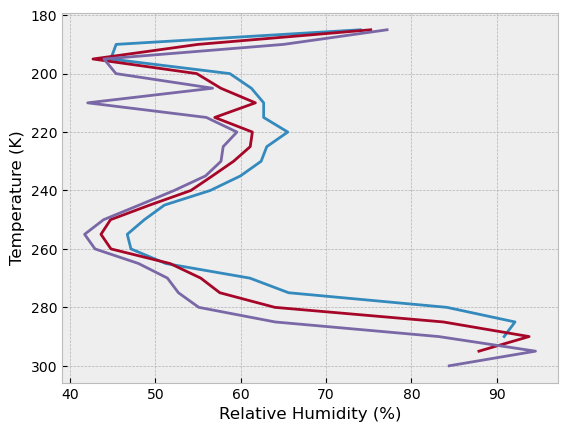

In [57]:
plt.figure()
for experiment in experiments_list:
    plt.plot(rh_mean[experiment], bins[:-1])
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Temperature (K)")
plt.gca().invert_yaxis()   # optional if you want warm at bottom
plt.show()

In [58]:
xr.open_dataset("/glade/campaign/univ/uwas0114/SST_AQP3_Qobs_27_4K_3h_10y/atm/hist/SST_AQP3_Qobs_27_4K_3h_20y.cam.h1.0003-10-24-75600.nc")

<xarray.Dataset> Size: 734MB
Dimensions:       (lat: 96, lon: 144, lev: 32, ilev: 33, time: 31, nbnd: 2)
Coordinates:
  * lat           (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon           (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) object 248B 0003-10-24 21:00:00 ... 0003-10-28 15:00:00
Dimensions without coordinates: nbnd
Data variables: (12/50)
    gw            (lat) float64 768B ...
    hyam          (lev) float64 256B ...
    hybm          (lev) float64 256B ...
    P0            float64 8B ...
    hyai          (ilev) float64 264B ...
    hybi          (ilev) float64 264B ...
    ...            ...
    SHFLX         (time, lat, lon) float32 2MB ...
    T             (time, lev, lat, lon) float32 55MB ...
    TMQ           (time, lat, lon) float32 2MB ...
    U             (time, lev, lat, lon) float32 55MB ...
    V             (time, lev, lat, lon) float32 55MB ...
    Z3            (time, lev, lat, lon) float32 55MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              SST_AQP3_Qobs_27_4K_3h_20y
    logname:           muting
    host:              cheyenne4
    initial_file:      /glade/p/cesmdata/cseg/inputdata/atm/cam/inic/fv/aqua_...
    topography_file:   bnd_topo
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_3

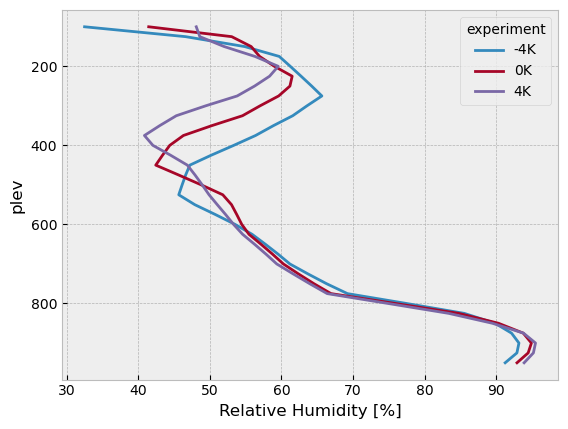

In [37]:
plt.style.use('bmh')
multi_experiment_variables_subset['Relative Humidity'].sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon']).plot(
    y='plev', yincrease=False, hue='experiment'
)
plt.show()

In [32]:
mean_precip = multi_experiment_variables_subset['Precipitation'].sel(lat=slice(-30,30)).mean(dim=['time', 'lat', 'lon'])
max_precip = multi_experiment_variables_subset['Precipitation'].sel(lat=slice(-30,30)).max(dim=['time', 'lat', 'lon'])

experiment_mean_surface_temp = multi_experiment_variables_subset['Temperature'].isel(plev=-1).sel(lat=slice(-30,30)).mean(dim=['time', 'lat', 'lon'])

In [33]:
print(
    f"Mean: {(100*(mean_precip.diff(dim='experiment')/mean_precip/experiment_mean_surface_temp.diff(dim='experiment')).mean()).values:0.1f}%/K"
)
print(
    f"Max: {(100*(max_precip.diff(dim='experiment')/max_precip/experiment_mean_surface_temp.diff(dim='experiment')).mean()).values:0.1f}%/K"
)


Mean: 2.9%/K
Max: 13.4%/K


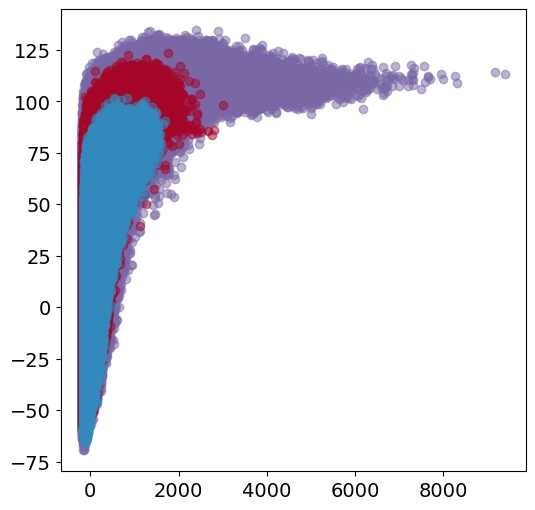

In [18]:
[fig, ax] = plt.subplots(1, 1, figsize=(6,6))

for index, experiment in enumerate(experiments_list):
    ax.scatter(
        standardize_data(
            (HEAT_OF_VAPORIZATION/SECONDS_PER_DAY)*multi_experiment_variables_subset['Precipitation'].sel(
                experiment=experiment,
                lat=slice(-15,15)
            ).stack(grid_points=('time', 'lat', 'lon')),
            dim='grid_points',
            unit_variance=False,
        ).values.flatten(),
        standardize_data(
            multi_experiment_variables_subset['Net Longwave Flux'].sel(
                experiment=experiment,
                lat=slice(-15,15)
            ).stack(grid_points=('time', 'lat', 'lon')),
            dim='grid_points',
            unit_variance=False,
        ).values.flatten(),
        color=bmh_colors(index+1),
        alpha=0.5,
        zorder=4-index
    )

## Filtered data

In [6]:
if not 'multi_experiment_variables_filtered' in locals():
    multi_experiment_variables_filtered = load_multi_experiment_processed_data(
        # variables_to_load,
        ['Precipitation', 'Outgoing Longwave Radiation',],#'Column Longwave Heating', 'Column Shortwave Heating'],
        'filtered'
    )
else:
    multi_experiment_variables_filtered = load_multi_experiment_processed_data(
        # variables_to_load,
        ['Precipitation', 'Outgoing Longwave Radiation',],#'Column Longwave Heating', 'Column Shortwave Heating'],
        'filtered',
        multi_experiment_variables_filtered,
        False
    )

         Loading filtered data          
(1/2) Precipitation...                  
----------------------------------------
Loading data...
    Experiment: -4K                    ✔
    Experiment: 0K                     ✔
    Experiment: 4K                     ✔
Concatenating data...                  ✔
(2/2) Outgoing Longwave Radiation...    
----------------------------------------
Loading data...
    Experiment: -4K                    ✔
    Experiment: 0K                     ✔
    Experiment: 4K                     ✔
Concatenating data...                  ✔
----------------------------------------
Data Loaded


## MJO-filtered

In [7]:
if not 'multi_experiment_variables_mjo_filtered' in locals():
    multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
        # variables_to_load,
        ['Precipitation', 'Outgoing Longwave Radiation',],# 'Column Longwave Heating', 'Column Shortwave Heating'],
        'mjo_filtered'
    )
else:
    multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
        # variables_to_load,
        ['Precipitation', 'Outgoing Longwave Radiation',],# 'Column Longwave Heating', 'Column Shortwave Heating'],
        'mjo_filtered',
        multi_experiment_variables_mjo_filtered,
        False
    )

       Loading mjo_filtered data        
(1/2) Precipitation...                  
----------------------------------------
Loading data...
    Experiment: -4K                    ✔
    Experiment: 0K                     ✔
    Experiment: 4K                     ✔
Concatenating data...                  ✔
(2/2) Outgoing Longwave Radiation...    
----------------------------------------
Loading data...
    Experiment: -4K                    ✔
    Experiment: 0K                     ✔
    Experiment: 4K                     ✔
Concatenating data...                  ✔
----------------------------------------
Data Loaded


In [32]:
multi_experiment_GMS_variables = {}
for variable_name in [
    'Horizontal MSE Advection',
    'Vertical MSE Advection',
    'Vertical DSE Advection',
]:
    multi_experiment_GMS_variables[variable_name] = xr.load_dataset(
        f"{data_directory}/MSE_budget_terms/daily_model-level_data/multi_experiment_{variable_name.lower().replace(' ', '_')}.nc"
    )[variable_name].drop_sel(time=missing_days, errors='ignore')
    multi_experiment_GMS_variables[variable_name].name = variable_name

multi_experiment_GMS_variables['Total MSE Advection'] = (
    multi_experiment_GMS_variables['Vertical MSE Advection']
    + multi_experiment_GMS_variables['Horizontal MSE Advection']
)

## Intraseasonally Filter GMS Variables

In [33]:
multi_experiment_intraseasonally_filtered_GMS_variables = {}

print(f"{f'Filtering variables...':^{str_width}}")
print(f"{'='*str_width}")
for index, (variable_name, variable_data) in enumerate(multi_experiment_GMS_variables.items()):
    print(f"{f'({index+1}/{len(multi_experiment_GMS_variables)}) {variable_name}...':<{str_width-1}}", end="")
    multi_experiment_intraseasonally_filtered_GMS_variables[variable_name] = {}
    for experiment in experiments_list:
        first_half = time_filter_data(variable_data.sel(
            experiment=experiment,
            time=first_half_subset_bounds
        ), slice(100, 20))
        second_half = time_filter_data(variable_data.sel(
            experiment=experiment,
            time=second_half_subset_bounds
        ), slice(100, 20))

        multi_experiment_intraseasonally_filtered_GMS_variables[variable_name][experiment] = xr.concat(
            [first_half, second_half], dim='time'
        ).drop_sel(time=missing_days, errors='ignore')

    multi_experiment_intraseasonally_filtered_GMS_variables[variable_name] = xr.concat(
        [multi_experiment_intraseasonally_filtered_GMS_variables[variable_name][experiment] for experiment in experiments_list],
        dim=experiments_array
    )
    print(rf"{'✔':>1}")
print(f"{'='*str_width}")
print("Finished")

         Filtering variables...         
(1/4) Horizontal MSE Advection...      ✔
(2/4) Vertical MSE Advection...        ✔
(3/4) Vertical DSE Advection...        ✔
(4/4) Total MSE Advection...           ✔
Finished


In [7]:
correlation = xr.dot(
    standardize_data(multi_experiment_intraseasonally_filtered_GMS_variables['Vertical MSE Advection'], dim='time', unit_variance=True),
    standardize_data(multi_experiment_intraseasonally_filtered_GMS_variables['Vertical DSE Advection'], dim='time', unit_variance=True),
    dim='time'
) / len(multi_experiment_intraseasonally_filtered_GMS_variables['Vertical DSE Advection'].time)

## MJO Filter GMS Variables

In [34]:
print(f"{'MJO filter variables':^{str_width}}")
print(f"{'='*str_width}")

variables_mjo_filtered = {}
multi_experiment_mjo_filtered_GMS_variables = {}

for index, (variable_name, variable_data) in enumerate(multi_experiment_intraseasonally_filtered_GMS_variables.items()):
    multi_experiment_mjo_filtered_GMS_variables[variable_name] = {}
    print(f"{f'({index+1}/{len(multi_experiment_intraseasonally_filtered_GMS_variables)}) {variable_name}...':<{str_width-1}}", end="")
    for experiment in experiments_list:

        first_half = mjo_filter_data(
            variable_data.sel(experiment=experiment, time=first_half_subset_bounds),
            wavenumber_bounds=slice(1, 3)
        ).real

        second_half = mjo_filter_data(
            variable_data.sel(experiment=experiment, time=second_half_subset_bounds),
            wavenumber_bounds=slice(1, 3)
        ).real

        multi_experiment_mjo_filtered_GMS_variables[variable_name][experiment] = xr.concat(
            (
                first_half,
                second_half,
            ),
            dim='time'
        )

    multi_experiment_mjo_filtered_GMS_variables[variable_name] = xr.concat(
        [multi_experiment_mjo_filtered_GMS_variables[variable_name][experiment] for experiment in experiments_list],
        dim=experiments_array
    )

print(f"{'='*str_width}")
print("Finished")

          MJO filter variables          
(1/4) Horizontal MSE Advection...      

/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glad

(2/4) Vertical MSE Advection...        

/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glad

(3/4) Vertical DSE Advection...        

/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glad

(4/4) Total MSE Advection...           

/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value


Finished


/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value


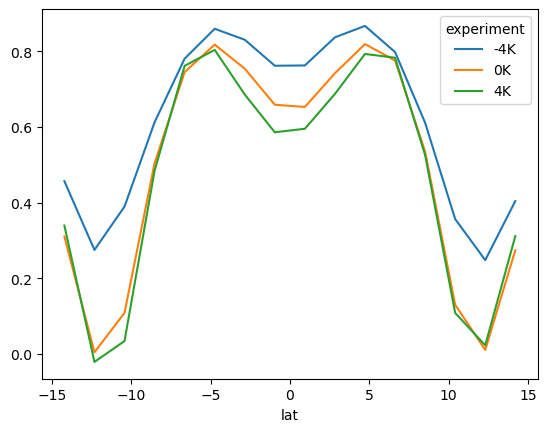

In [16]:
correlation = xr.dot(
    standardize_data(multi_experiment_mjo_filtered_GMS_variables['Vertical MSE Advection'], dim='time', unit_variance=True),
    standardize_data(multi_experiment_mjo_filtered_GMS_variables['Vertical DSE Advection'], dim='time', unit_variance=True),
    dim='time'
) / len(multi_experiment_intraseasonally_filtered_GMS_variables['Vertical DSE Advection'].time)
correlation.sel(lat=slice(-15,15)).mean(dim='lon').plot(x='lat', hue='experiment')

## Calculate mean nGMS quantities

In [12]:
time_mean_nGMS = (
    multi_experiment_GMS_variables['Horizontal MSE Advection']
    + multi_experiment_GMS_variables['Vertical MSE Advection']
).mean(dim=['time']) / (multi_experiment_GMS_variables['Vertical DSE Advection']).mean(dim='time')

spatial_mean_nGMS = xr.concat(
    [(
            multi_experiment_GMS_variables['Horizontal MSE Advection']
            + multi_experiment_GMS_variables['Vertical MSE Advection']
        ).sel(experiment=experiment, lat=slice(*latitude_bounds[experiment])).mean(dim=['lat', 'lon'])
        / (multi_experiment_GMS_variables['Vertical DSE Advection']).sel(experiment=experiment, lat=slice(*latitude_bounds[experiment])).mean(dim=['lat', 'lon'])
    for experiment in experiments_list],
    dim=experiments_array
)

intraseasonally_filtered_spatial_mean_GMS = {}
for experiment in experiments_list:
    first_half = time_filter_data(spatial_mean_nGMS.sel(
        experiment=experiment,
        time=first_half_subset_bounds
    ), slice(100, 20))
    second_half = time_filter_data(spatial_mean_nGMS.sel(
        experiment=experiment,
        time=second_half_subset_bounds
    ), slice(100, 20))

    intraseasonally_filtered_spatial_mean_GMS[experiment] = xr.concat([first_half, second_half], dim='time').drop_sel(time=missing_days, errors='ignore')

multi_experiment_intraseasonally_filtered_spatial_mean_GMS = xr.concat(
    [intraseasonally_filtered_spatial_mean_GMS[experiment] for experiment in experiments_list],
    dim=experiments_array
)

# fontsize = 16
# plt.rcParams.update({'font.size':fontsize})
# fig = plt.figure(figsize=(9, 12))
# gs = fig.add_gridspec(3, 1, hspace=0.3)
# gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

# axes_list = []
# axes_list.append(fig.add_subplot(gs[0]))
# axes_list.append(fig.add_subplot(gs[1]))
# axes_list.append(fig.add_subplot(gs[2]))

# for index, (ax, experiment) in enumerate(zip(axes_list, experiments_list)):
#     nGMS.sel(experiment=experiment).plot(levels=np.linspace(-10, 10, 21), extend='both', ax=ax)

# latitude_bounds = {}
# latitude_bounds['-4K'] = (-5, 5)
# latitude_bounds['0K'] = (-10, 10)
# latitude_bounds['4K'] = (-15, 15)

# reference_GMS = {}
# for experiment in experiments_list:
#     reference_GMS[experiment] = nGMS.sel(experiment=experiment, lat=slice(*latitude_bounds[experiment])).mean(dim=['lat', 'lon'])

# filtered_reference_GMS = {}
# for experiment in experiments_list:
#     first_half = time_filter_data(reference_GMS[experiment].sel(time=first_half_subset_bounds), slice(100, 20))
#     second_half = time_filter_data(reference_GMS[experiment].sel(time=second_half_subset_bounds), slice(100, 20))

#     filtered_reference_GMS[experiment] = xr.concat([first_half, second_half], dim='time')

# multi_experiment_filtered_reference_GMS = xr.concat(
#     [filtered_reference_GMS[experiment] for experiment in experiments_list],
#     dim=experiments_array
# )


In [7]:
# savefig = False
# component_to_plot = 'Vertical'

# slope = {}
# intercept = {}
# import matplotlib.patheffects as pe

# fontsize = 16
# plt.rcParams.update({'font.size':fontsize})
# fig = plt.figure(figsize=(16, 6))
# gs = fig.add_gridspec(1, 2, wspace=0.2, width_ratios=[180, 90])
# gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

# axes_list = []
# axes_list.append(fig.add_subplot(gs[0]))
# axes_list.append(fig.add_subplot(gs[1]))

# seed = 235913091
# random.seed(seed)
# random_sample = random.sample(range(0, len(denominator) + 1), 10000)

# numerator = {}
# denominator = {}



# for ax, data_type in zip(axes_list, (multi_experiment_GMS_variables, multi_experiment_intraseasonally_filtered_GMS_variables)):

#     for index, experiment in enumerate(experiments_list):

#         data_type['Total MSE Advection'] = data_type['Vertical MSE Advection'] + data_type['Horizontal MSE Advection']
#         denominator[experiment] = data_type['Vertical DSE Advection'].sel(experiment=experiment, lat=slice(*latitude_bounds[experiment]))
#         numerator[experiment] = (data_type[f"{component_to_plot} MSE Advection"]).sel(experiment=experiment, lat=slice(*latitude_bounds[experiment]))

#         denominator[experiment] = standardize_data(denominator[experiment].values.flatten(), dim='time', unit_variance=False)
#         print(experiment, np.max(denominator[experiment]))
#         numerator[experiment] = standardize_data(numerator[experiment].values.flatten(), dim='time', unit_variance=False)

#         slope[experiment], intercept[experiment] = np.polyfit(
#             y=numerator[experiment],
#             x=denominator[experiment],
#             deg=1
#         )

#         # ax.scatter(
#         #     denominator,
#         #     numerator,
#         #     c=bmh_colors(index+1),
#         #     edgecolor='k',
#         #     linewidths=0.2,
#         #     alpha=0.5,
#         #     label=f"{f'{experiments_array.sel(experiment=experiment)['name'].item()}':<4} (slope={slope[experiment]:>1.2f})"
#         # )
#         sns.kdeplot(
#             ax=ax,
#             x=denominator[experiment][random_sample],
#             y=numerator[experiment][random_sample],
#             fill=True,
#             color=bmh_colors(index+1),
#             alpha=0.75,
#         )

#         # ax.scatter(
#         #     denominator,
#         #     slope[experiment]*denominator+intercept[experiment],
#         #     marker='o',
#         #     color=bmh_colors(index+1),
#         #     edgecolor='k',
#         #     linewidths=0.5,
#         #     # mfc=bmh_colors(index+1),
#         #     # mec='k',
#         #     # mew=0.2,
#         #     # lw=4,
#         #     alpha=0.5,
#         #     label=f"{f'{experiments_array.sel(experiment=experiment)['name'].item()}':<4} (slope={slope[experiment]:>1.2f})",
#         #     zorder=10
#         # )
#         ax.plot(
#             denominator[experiment],
#             slope[experiment]*denominator[experiment]+intercept[experiment],
#             # marker='o',
#             color=bmh_colors(index+1),
#             # color='lightgray',
#             # edgecolor='k',
#             lw=3,
#             # mfc=bmh_colors(index+1),
#             # mec='k',
#             # mew=0.2,
#             # lw=4,
#             # alpha=0.5,
#             label=f"{f'{experiments_array.sel(experiment=experiment)['name'].item()}':<4} (slope={slope[experiment]:>1.2f})",
#             zorder=10,
#             # path_effects=[pe.Stroke(linewidth=4, foreground=bmh_colors(index+1)), pe.Normal()]
#         )

#     # ax.set_ylim(-20, 50)
#     # ax.set_aspect('equal')
#     ax.set_xlabel(r'Vertical DSE Advection (W m$^{-2}$)')
#     ax.set_ylabel(rf'{component_to_plot} MSE Advection (W m$^{-2}$)')
#     ax.legend(fontsize=12)
#     ax.axhline(y=0, color='gray', ls=':')
#     ax.axvline(x=0, color='gray', ls=':')

# axes_list[0].set_title(f'a) {component_to_plot} GMS Constituents', loc='left')
# axes_list[1].set_title(f'b) Intraseasonally-filtered \n {component_to_plot} GMS Constituents', loc='left')
# # axes_list[0].set_xlim(40, 300)
# # axes_list[0].set_ylim(-10, 40)
# # axes_list[0].set_xlim(-80, 100)
# # axes_list[0].set_ylim(-20, 20)
# # axes_list[1].set_xlim(-40, 50)
# # axes_list[1].set_ylim(-20, 20)
# # axes_list[1].set_aspect('equal')


# output_filename = f"Zero Centered {component_to_plot} GMS Constituents Scatter Plot"
# print(f"Output directory: {aquaplanet_output_directory}/gross_moist_stability_analysis/")
# print(f"Output filename: {output_filename}")
# if savefig:
#     print(f"{f'Saving...':<{str_width-1}}", end="")
#     plt.savefig(
#         f"{aquaplanet_output_directory}/gross_moist_stability_analysis/{output_filename}.png",
#         dpi=500,
#         bbox_inches="tight",
#     )
#     print(rf"{'✔':>1}")
# else:
#     print("Not Saving")
#     plt.show()

In [8]:
# component_to_plot = 'Vertical'

# latitude_bounds = xr.DataArray(
#     [[-5, -10, -15], [5, 10, 15]],
#     dims=["bound", "experiment"],
#     coords={"bound":['lower', 'upper'], "experiment": experiments_array}
# )

# # Mask and filter
# lat_mask = (
#     (multi_experiment_GMS_variables['Vertical MSE Advection'].lat >= latitude_bounds.sel(bound='lower')) &
#     (multi_experiment_GMS_variables['Vertical MSE Advection'].lat <= latitude_bounds.sel(bound='upper'))
# )

# denominator = multi_experiment_GMS_variables['Vertical DSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
# denominator = standardize_data(denominator, dim='grid_points', unit_variance = False)

# numerator = multi_experiment_GMS_variables[f'{component_to_plot} MSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
# numerator = standardize_data(numerator, dim='grid_points', unit_variance = False)

# slope = xr.zeros_like(experiments_array).astype('float64')
# intercept = xr.zeros_like(experiments_array).astype('float64')
# for experiment_index, experiment in enumerate(experiments_list):
#     slope[experiment_index], intercept[experiment_index] = np.polyfit(
#         y=numerator.sel(experiment=experiment).dropna(dim='grid_points'),
#         x=denominator.sel(experiment=experiment).dropna(dim='grid_points'),
#         deg=1
#     )

/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1108064898.py:86: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1108064898.py:86: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1108064898.py:86: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1108064898.py:86: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1108064898.py:86: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1108064898.py:86: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1108064898.py:86: RuntimeWarning: divi

Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//gross_moist_stability_analysis/
Output filename: Zero Centered Vertical GMS Constituents Scatter Plot - Log(Histogram)
Not Saving


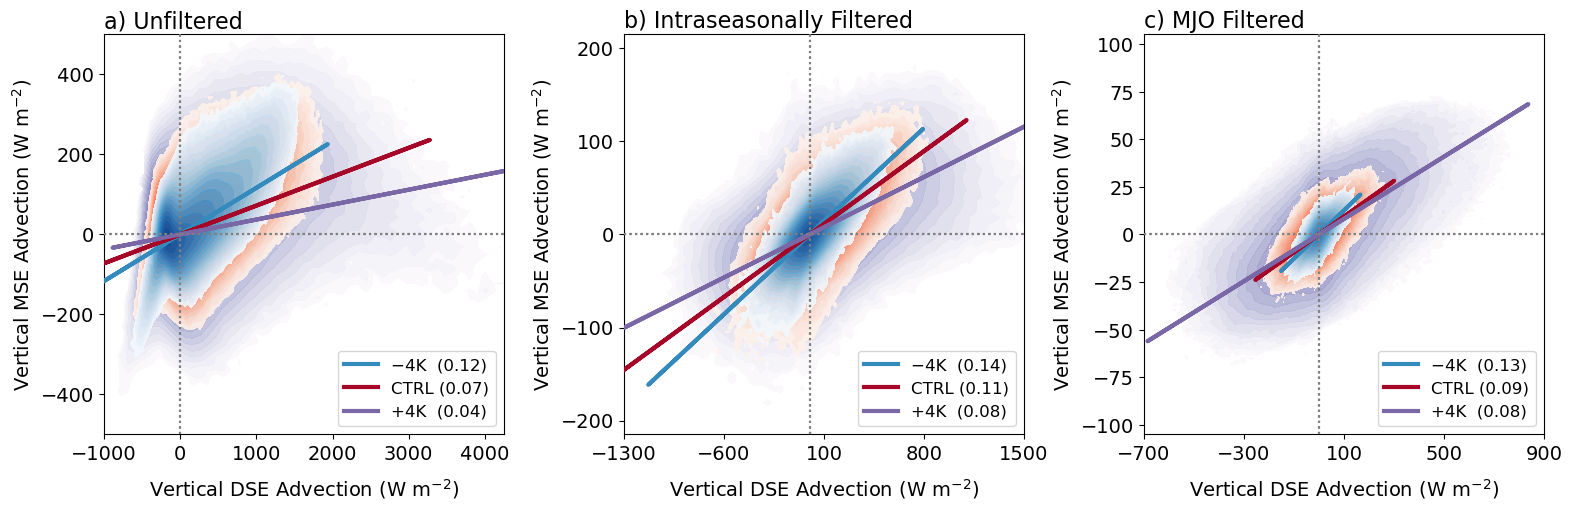

In [35]:
savefig = False
recalculate = True

component_to_plot = 'Vertical'

latitude_bounds = xr.DataArray(
    # [[-5, -10, -15], [5, 10, 15]],
    # [[-30, -30, -30], [30, 30, 30]],
    [[-15, -15, -15], [15, 15, 15]],
    dims=["bound", "experiment"],
    coords={"bound":['lower', 'upper'], "experiment": experiments_array}
)

experiment_cmaps = {}
experiment_cmaps['-4K'] = 'Blues'
experiment_cmaps['0K'] = 'Reds'
experiment_cmaps['4K'] = 'Purples'

all_variables_dict = {
    'Unfiltered': multi_experiment_GMS_variables,
    'Intraseasonally Filtered': multi_experiment_intraseasonally_filtered_GMS_variables,
    'MJO Filtered': multi_experiment_mjo_filtered_GMS_variables
}

# Mask and filter
lat_mask = (
    (multi_experiment_GMS_variables['Vertical MSE Advection'].lat >= latitude_bounds.sel(bound='lower')) &
    (multi_experiment_GMS_variables['Vertical MSE Advection'].lat <= latitude_bounds.sel(bound='upper'))
)

if 'denominator' not in locals() or recalculate:
    denominator, numerator, GMS_estimate, intercept = {}, {}, {}, {}
    for dict_name, dict_values  in all_variables_dict.items():
        denominator[dict_name] = dict_values['Vertical DSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
        denominator[dict_name] = standardize_data(denominator[dict_name], dim='grid_points', unit_variance = False)

        numerator[dict_name] = dict_values[f'{component_to_plot} MSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
        numerator[dict_name] = standardize_data(numerator[dict_name], dim='grid_points', unit_variance = False)

        GMS_estimate[dict_name] = xr.zeros_like(experiments_array).astype('float64')
        intercept[dict_name] = xr.zeros_like(experiments_array).astype('float64')
        for experiment_index, experiment in enumerate(experiments_list):
            GMS_estimate[dict_name][experiment_index], intercept[dict_name][experiment_index] = np.polyfit(
                y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
                x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
                deg=1
            )
            # num_aligned, denom_aligned = xr.align(numerator[dict_name].sel(experiment=experiment), denominator[dict_name].sel(experiment=experiment))
            # data = xr.concat([denom_aligned, num_aligned], dim="variable")
            # data = data.assign_coords(variable=["denom", "num"])
            # model = xe.single.EOF(n_modes=1)
            # model.fit(data, dim="grid_points")
            # eof = model.components()  # dims: (mode, variable)
            # direction = eof.sel(mode=1)
            # dx = direction.sel(variable="denom").item()
            # dy = direction.sel(variable="num").item()
            # GMS_estimate[dict_name][experiment_index] = dy / dx
            # # intercept
            # x_mean = denom_aligned.mean().item()
            # y_mean = num_aligned.mean().item()

            # intercept[dict_name][experiment_index] = y_mean - GMS_estimate[dict_name][experiment_index] * x_mean

fontsize = 14
plt.rcParams.update({'font.size':fontsize})
plt.rcParams['mathtext.fontset'] = 'dejavusans'
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 3, wspace=0.3)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

axes_list = []
axes_list.append(fig.add_subplot(gs[0]))
axes_list.append(fig.add_subplot(gs[1]))
axes_list.append(fig.add_subplot(gs[2]))

for ax_index, (ax, (dict_name, dict_values))  in enumerate(zip(axes_list, all_variables_dict.items())):
    ax.set_title(f'{string.ascii_letters[ax_index]}) {dict_name}', loc='left', pad=5, fontsize=fontsize+2)
    for index, experiment in enumerate(experiments_list):

        counts,xbins,ybins = np.histogram2d(
            x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
            y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
            bins=[100, 100],
        )
        im = ax.contourf(
            np.log10(counts.transpose()),
            # counts.transpose(),
            extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
            cmap=experiment_cmaps[experiment],
            # levels = np.linspace(10, np.nanmax(counts), 21),
            levels=np.linspace(np.log10(10), 6, 21),
            alpha=0.9,
            zorder = 4-index
        )
        ax.plot(
                denominator[dict_name].sel(experiment=experiment),
                (GMS_estimate[dict_name]*denominator[dict_name]+intercept[dict_name]).sel(experiment=experiment),
                color=bmh_colors(index+1),
                lw=3,
                # label=f"{experiments_array.sel(experiment=experiment)['name'].item():<4} (GMS={GMS_estimate[dict_name].sel(experiment=experiment):>1.2f})",
                label=f"{experiments_array.sel(experiment=experiment)['name'].item():<4} ({GMS_estimate[dict_name].sel(experiment=experiment):>1.2f})",
                zorder=10,
            )
        ax.axhline(y=0, color='gray', ls=':', zorder=10)
        ax.axvline(x=0, color='gray', ls=':', zorder=10)
        # ax.set_ylim(-500, 500)

    ax.set_xlabel(r'Vertical DSE Advection (W m$^{-2}$)', labelpad=10, fontsize=fontsize)
    ax.set_ylabel(rf'{component_to_plot} MSE Advection (W m$^{{{-2}}}$)', labelpad=5, fontsize=fontsize)
    ax.legend(loc='lower right', fontsize=fontsize-2)



# Unfiltered
axes_list[0].set_xlim(-1000, 4250)
axes_list[0].set_xticks(np.arange(-1000, 5000, 1000))
axes_list[0].set_ylim(-500, 500)

# Intraseasonally Filtered
axes_list[1].set_xlim(-1300, 1500)
axes_list[1].set_xticks(np.arange(-1300, 1500+700, 700))
axes_list[1].set_ylim(-215, 215)
axes_list[1].set_yticks(np.arange(-200, 300, 100))

# MJO Filtered
axes_list[2].set_xlim(-700, 900)
axes_list[2].set_xticks(np.arange(-700, 900+400, 400))
axes_list[2].set_ylim(-105, 105)
axes_list[2].set_yticks(np.arange(-100, 125, 25))

for axis in axes_list:
    axis.set_aspect((axis.get_xlim()[1] - axis.get_xlim()[0])/(axis.get_ylim()[1] - axis.get_ylim()[0]))

# Save figure
output_filename = f"Zero Centered {component_to_plot} GMS Constituents Scatter Plot - Log(Histogram)"
print(f"Output directory: {aquaplanet_output_directory}/gross_moist_stability_analysis/")
print(f"Output filename: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{str_width-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/gross_moist_stability_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

In [21]:
for experiment in experiments_list:
    num_aligned, denom_aligned = xr.align(numerator['Unfiltered'].sel(experiment=experiment), denominator['Unfiltered'].sel(experiment=experiment))
    data = xr.concat([denom_aligned, num_aligned], dim="variable")
    data = data.assign_coords(variable=["denom", "num"])
    model = xe.single.EOF(n_modes=1)
    model.fit(data, dim="grid_points")
    eof = model.components()  # dims: (mode, variable)
    direction = eof.sel(mode=1)
    dx = direction.sel(variable="denom").item()
    dy = direction.sel(variable="num").item()
    slope = dy / dx
    print(slope)

0.11996328869078521
0.0746908255559951
0.03886577965957671


/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: Runtim

Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//gross_moist_stability_analysis/
Output filename: Zero Centered Horizontal GMS Constituents Multi-Experiment Log(Histogram)
Not Saving


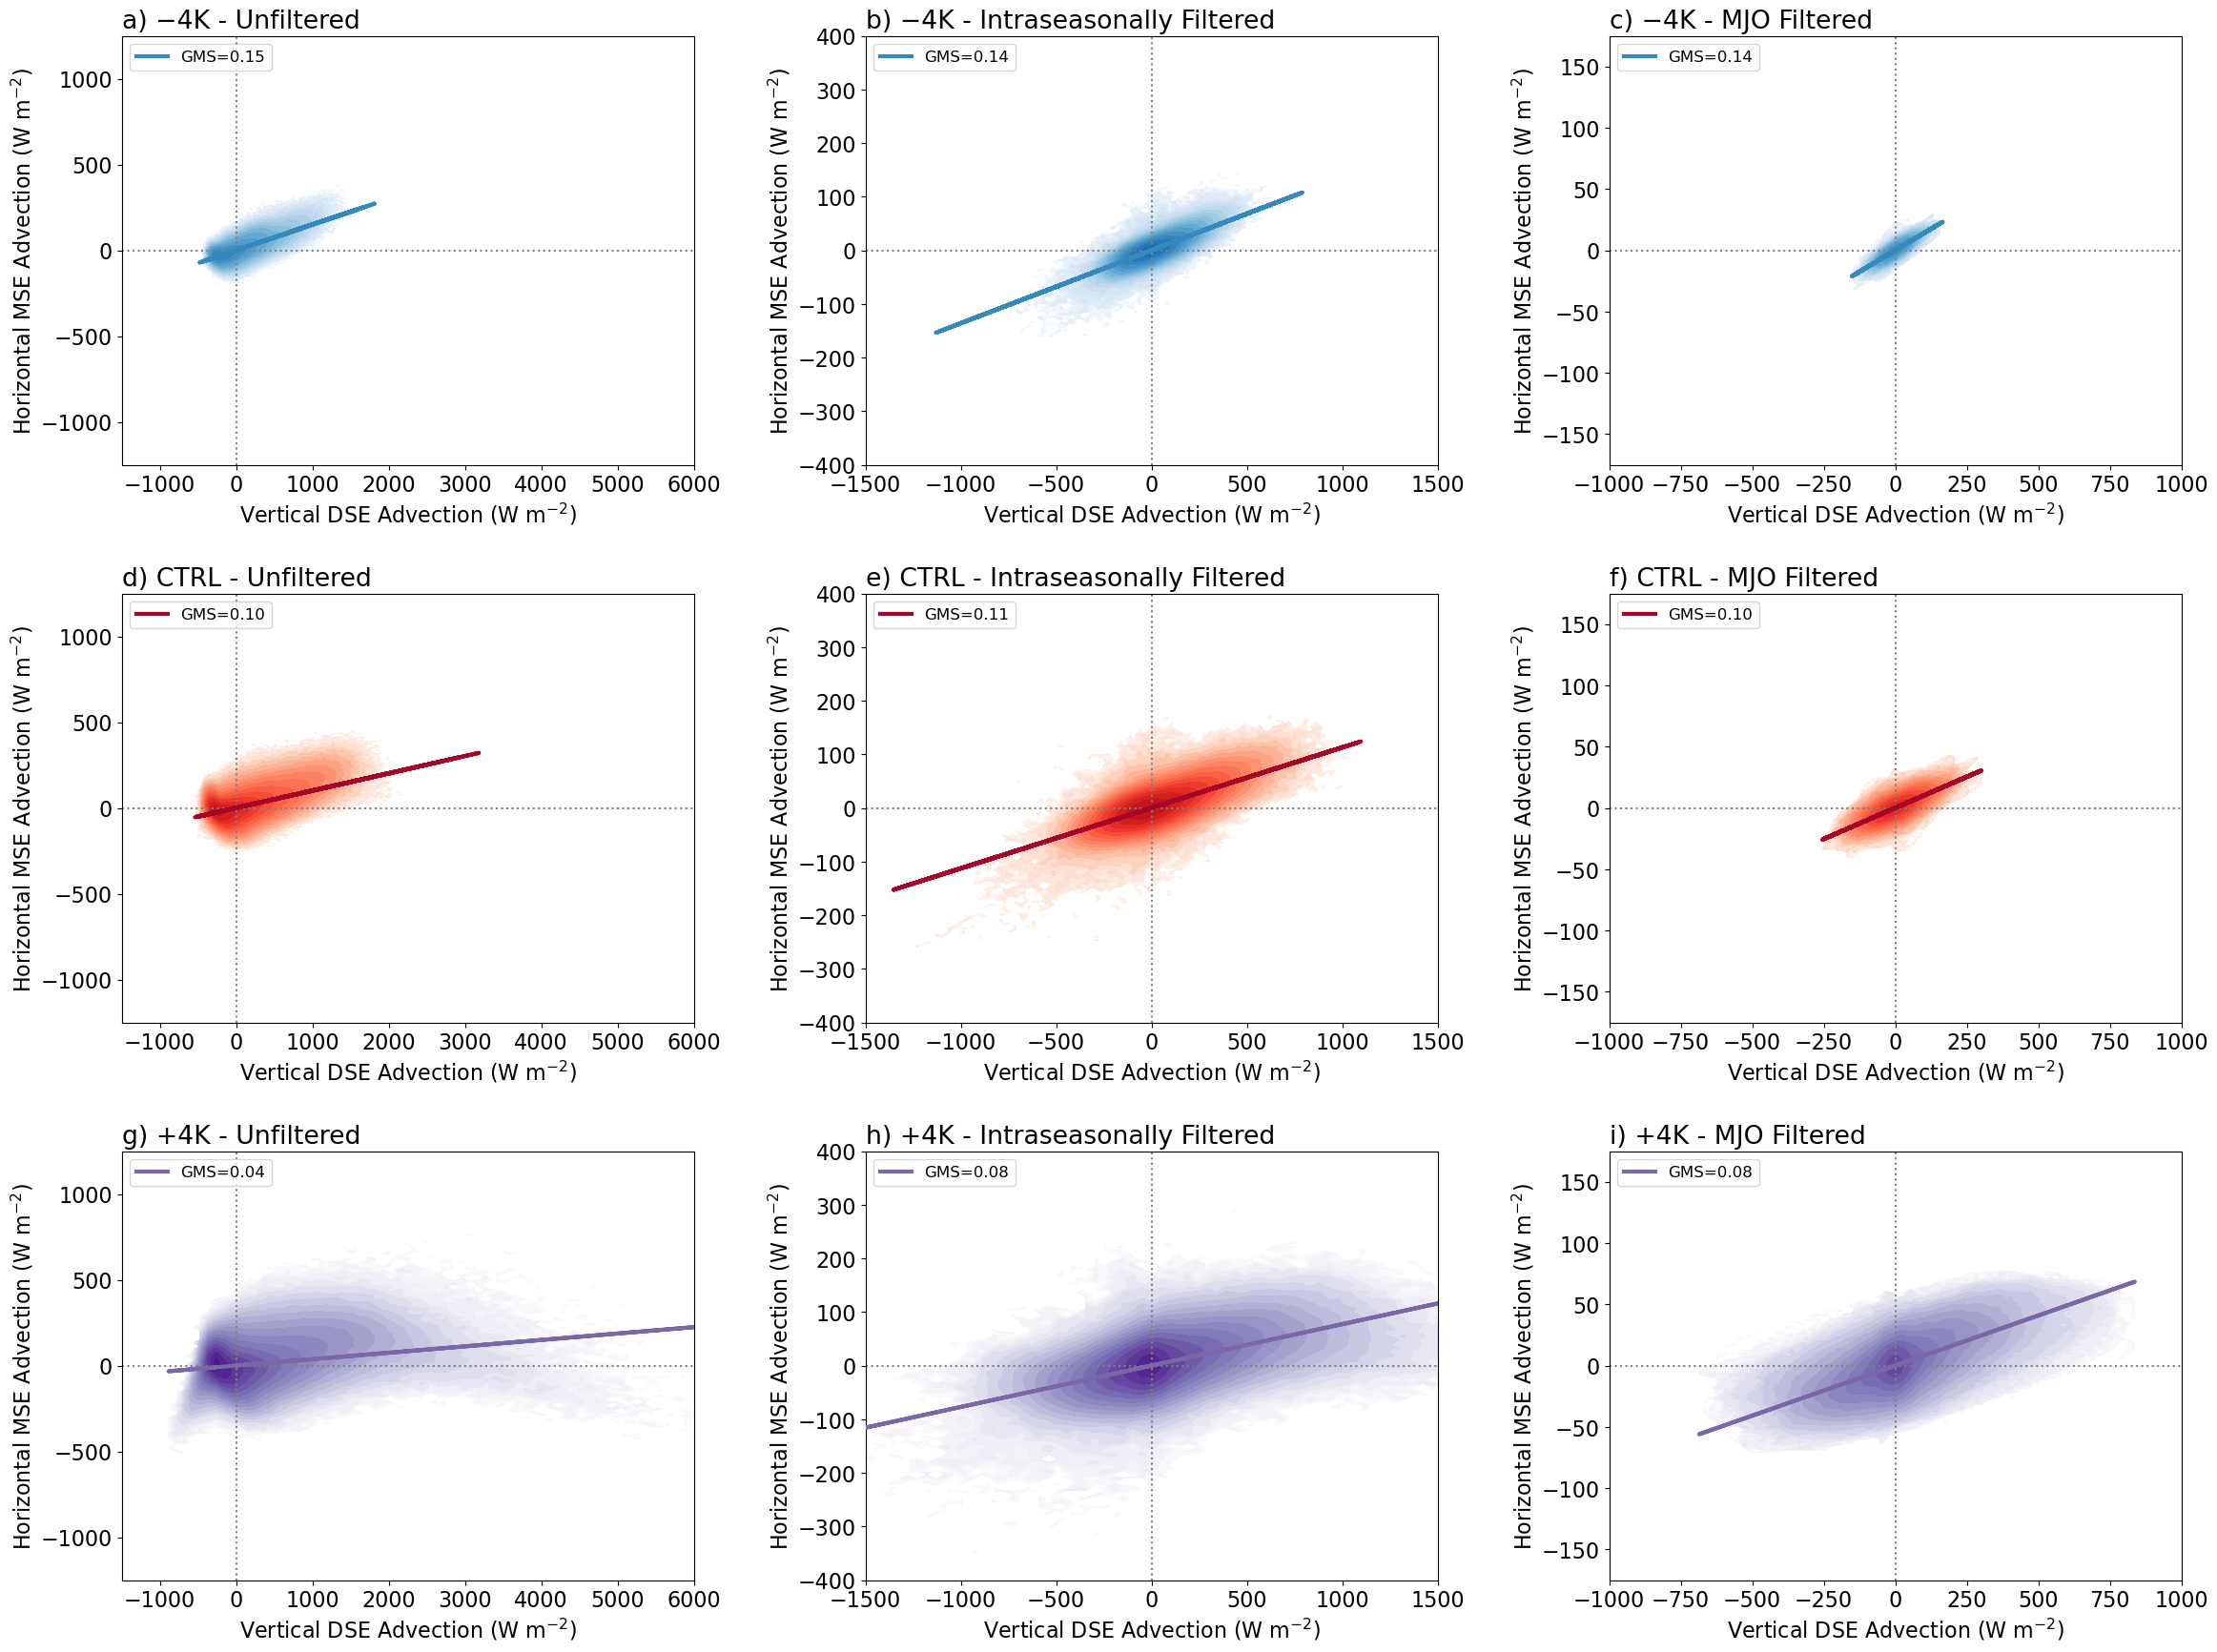

In [8]:
savefig = False
recalculate = False
seed = 235913091
random.seed(seed)
sample_points = 10000

latitude_bounds = xr.DataArray(
    [[-5, -10, -15], [5, 10, 15]],
    dims=["bound", "experiment"],
    coords={"bound":['lower', 'upper'], "experiment": experiments_array}
)
experiment_cmaps = {}
experiment_cmaps['-4K'] = 'Blues'
experiment_cmaps['0K'] = 'Reds'
experiment_cmaps['4K'] = 'Purples'

component_to_plot = 'Horizontal'

all_variables_dict = {
    'Unfiltered': multi_experiment_GMS_variables,
    'Intraseasonally Filtered': multi_experiment_intraseasonally_filtered_GMS_variables,
    'MJO Filtered': multi_experiment_mjo_filtered_GMS_variables
}

# Mask and filter
lat_mask = (
    (multi_experiment_GMS_variables['Vertical MSE Advection'].lat >= latitude_bounds.sel(bound='lower')) &
    (multi_experiment_GMS_variables['Vertical MSE Advection'].lat <= latitude_bounds.sel(bound='upper'))
)

if 'denominator' not in locals() or recalculate:
    denominator, numerator, slope, intercept = {}, {}, {}, {}
    for dict_name, dict_values  in all_variables_dict.items():
        denominator[dict_name] = dict_values['Vertical DSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
        denominator[dict_name] = standardize_data(denominator[dict_name], dim='grid_points', unit_variance = False)

        numerator[dict_name] = dict_values[f'{component_to_plot} MSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
        numerator[dict_name] = standardize_data(numerator[dict_name], dim='grid_points', unit_variance = False)

        slope[dict_name] = xr.zeros_like(experiments_array).astype('float64')
        intercept[dict_name] = xr.zeros_like(experiments_array).astype('float64')
        for experiment_index, experiment in enumerate(experiments_list):
            slope[dict_name][experiment_index], intercept[dict_name][experiment_index] = np.polyfit(
                y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
                x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
                deg=1
            )

fontsize = 16
plt.rcParams.update({'font.size':fontsize})
fig = plt.figure(figsize=(24, 18))
gs = fig.add_gridspec(3, 3, wspace=0.3, hspace=0.3, width_ratios=[1, 1, 1])
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

axes_list = []
axes_list.append(fig.add_subplot(gs[0,0]))
axes_list.append(fig.add_subplot(gs[0,1]))
axes_list.append(fig.add_subplot(gs[0,2]))
axes_list.append(fig.add_subplot(gs[1,0]))
axes_list.append(fig.add_subplot(gs[1,1]))
axes_list.append(fig.add_subplot(gs[1,2]))
axes_list.append(fig.add_subplot(gs[2,0]))
axes_list.append(fig.add_subplot(gs[2,1]))
axes_list.append(fig.add_subplot(gs[2,2]))

# for ax_index, (ax, (dict_name, dict_values))  in enumerate(zip(axes_list, all_variables_dict.items())):
for var_index, (dict_name, dict_values) in enumerate(all_variables_dict.items()):
    for experiment_index, experiment in enumerate(experiments_list):
        # ax_index = 3*var_index + experiment_index
        ax_index = 3*experiment_index + var_index

        # random_sample = random.sample(range(0, len(denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')) + 1), sample_points)
        # sample_percentage = len(random_sample)/len(denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'))

        # axes_list[ax_index].scatter(
        #     x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')[::100],
        #     y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')[::100],
        #     color=bmh_colors(experiment_index+1),
        #     alpha=0.5
        # )
        # sns.kdeplot(
        #     ax=ax,
        #     x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')[random_sample],
        #     y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')[random_sample],
        #     fill=True,
        #     color=bmh_colors(index+1),
        #     alpha=0.75
        # )
        counts,xbins,ybins = np.histogram2d(
            x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
            y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
            bins=[100, 100],
        )
        im = axes_list[ax_index].contourf(
            np.log10(counts.transpose()),
            # counts.transpose(),
            extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
            cmap=experiment_cmaps[experiment],
            # levels = np.linspace(10, np.nanmax(counts), 21),
            levels=np.linspace(0.1, 6, 21),
            alpha=1.0
        )
        axes_list[ax_index].plot(
                denominator[dict_name].sel(experiment=experiment),
                (slope[dict_name]*denominator[dict_name]+intercept[dict_name]).sel(experiment=experiment),
                color=bmh_colors(experiment_index+1),
                lw=3,
                label=f"GMS={slope[dict_name].sel(experiment=experiment):>1.2f}",
                zorder=10,
            )

        if var_index == 0:
            axes_list[ax_index].set_xlim(-1500, 6000)
            # axes_list[ax_index].set_ylim(-500, 500)
            axes_list[ax_index].set_ylim(-1250, 1250)

        elif var_index == 1:
            axes_list[ax_index].set_xlim(-1500, 1500)
            # axes_list[ax_index].set_ylim(-250, 250)
            axes_list[ax_index].set_ylim(-400, 400)

        else:
            axes_list[ax_index].set_xlim(-1000, 1000)
            # axes_list[ax_index].set_ylim(-150, 150)
            axes_list[ax_index].set_ylim(-175, 175)

        axes_list[ax_index].set_xlabel(r'Vertical DSE Advection (W m$^{-2}$)')
        axes_list[ax_index].set_ylabel(rf'{component_to_plot} MSE Advection (W m$^{{{-2}}}$)')
        axes_list[ax_index].legend(fontsize=12, loc='upper left')
        axes_list[ax_index].axhline(y=0, color='gray', ls=':')
        axes_list[ax_index].axvline(x=0, color='gray', ls=':')
        axes_list[ax_index].set_title(
            (
                f"{string.ascii_letters[ax_index]}) "
                f"{experiments_array.sel(experiment=experiment)['name'].item()} - "
                f"{dict_name}"
            ),
            loc='left'
        )

# axes_list[0].set_title(
#     (
#         f'a) {component_to_plot} GMS Constituents'
#         +(f", (Plot: {100*sample_percentage:0.1f}% Sample)" if sample_percentage < 1 else "")
#     ),
#     loc='left'
# )

output_filename = f"Zero Centered {component_to_plot} GMS Constituents Multi-Experiment Log(Histogram)"
print(f"Output directory: {aquaplanet_output_directory}/gross_moist_stability_analysis/")
print(f"Output filename: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{str_width-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/gross_moist_stability_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

# Convective Adjustment Timescale

KeyError: 'Column Water Vapor'

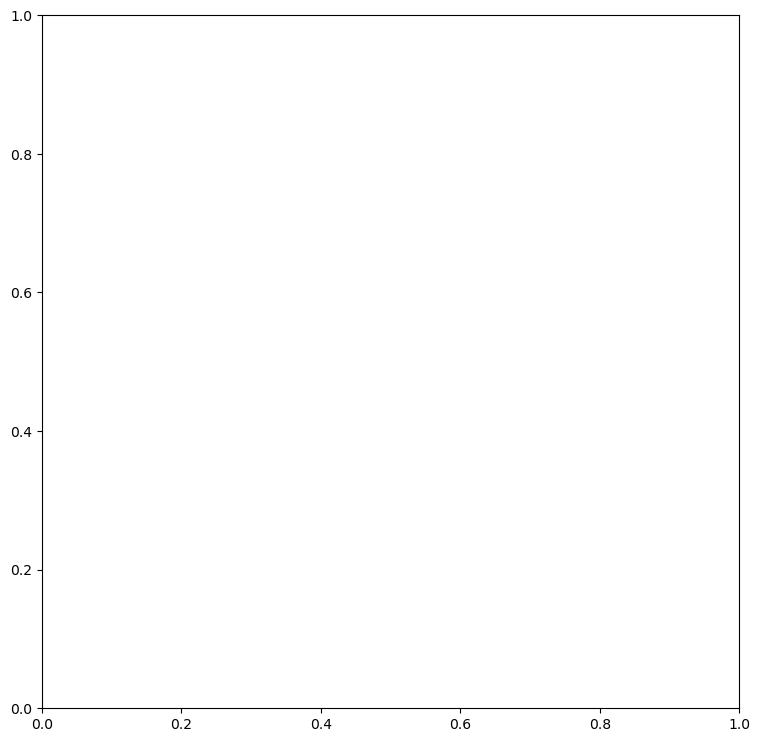

In [10]:
savefig=False
# longitude_bounds = (179, 181)

latitude_bounds = {}
latitude_bounds['-4K'] = (-5, 5)
latitude_bounds['0K'] = (-10, 10)
latitude_bounds['4K'] = (-15, 15)


# seed = 235913091
# random.seed(seed)
# random_sample = random.sample(range(0, len(flat_cwv) + 1), 1000)

convective_adjustment_timescale, slope, intercept = {}, {}, {}
[fig, ax] = plt.subplots(1, 1, figsize=(9,9))
for index, experiment in enumerate(experiments_list):

    standardized_column_water_vapor = standardize_data(
            multi_experiment_variables_subset['Column Water Vapor'],
            dim='time',
            unit_variance=False
        ).sel(experiment=experiment, lat=slice(*latitude_bounds[experiment]))

    standardized_precipitation = standardize_data(
            multi_experiment_variables_subset['Precipitation'],
            dim='time',
            unit_variance=False
        ).sel(experiment=experiment, lat=slice(*latitude_bounds[experiment]))

    flat_cwv = standardized_column_water_vapor.values.flatten()
    flat_precip = standardized_precipitation.values.flatten()

    slope[experiment], intercept[experiment] = np.polyfit(
            y=flat_precip,
            x=flat_cwv,
            deg=1
        )
    convective_adjustment_timescale[experiment] = 24/slope[experiment]

    # Plot
    ax.set_title(
        # f"({tick_labeller([longitude_bounds[0]], 'lon')[0]}"
        # f"-{tick_labeller([longitude_bounds[1]], 'lon')[0]})"
        "ALL LON"
        # f"{tick_labeller([180], 'lon')[0]}"
    )
    # sns.kdeplot(
    #     ax=ax,
    #     x=flat_cwv[random_sample],
    #     y=flat_precip[random_sample],
    #     fill=True,
    #     color=bmh_colors(index+1),
    #     alpha=0.9
    # )
    # ax.scatter(
    #     x=flat_cwv[random_sample],
    #     y=flat_precip[random_sample],
    #     color=bmh_colors(index+1),
    #     alpha=0.5
    # )
    counts,xbins,ybins = np.histogram2d(
        x=flat_cwv,
        y=flat_precip,
        bins=[100, 100],
    )
    im = ax.contourf(
        np.log10(counts.transpose()),
        # counts.transpose(),
        extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
        cmap=experiment_cmaps[experiment],
        # levels = np.linspace(10, np.nanmax(counts), 21),
        levels=np.linspace(0.1, 6, 21),
        alpha=1.0,
        zorder = 4-index
    )
    ax.plot(
            flat_cwv,
            slope[experiment]*flat_cwv+intercept[experiment],
            # marker='o',
            color=bmh_colors(index+1),
            # color='lightgray',
            # edgecolor='k',
            lw=3,
            # mfc=bmh_colors(index+1),
            # mec='k',
            # mew=0.2,
            # lw=4,
            # alpha=0.5,
            zorder=10,
            label=(
            rf"{f'{experiments_array.sel(experiment=experiment)['name'].item()}':<4}"
            rf" ($\tau_c$={convective_adjustment_timescale[experiment]:>1.1f} hr)"
            ),
    )

ax.axhline(y=0, color='gray', ls=':')
ax.axvline(x=0, color='gray', ls=':')

ax.set_ylabel(r'Precipitation (mm day$^{-1}$)')
ax.set_xlabel(r'Column Water Vapor (mm)')
# ax.set_xlim(-25, 25)
# ax.set_ylim(-25, 25)
# ax.set_xticks(np.arange(-25, 30, 5))
# ax.set_yticks(np.arange(-25, 30, 5))

ax.legend(loc='upper left')
ax.set_ylim(-50, 150)

output_filename = (
    "PRCP-CWV_ALL_LON_convective_adjustment_timescale"
)
print(f"Output directory: {aquaplanet_output_directory}/gross_moist_stability_analysis/")
print(f"Output file: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{str_width-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/gross_moist_stability_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight"
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

In [52]:
convective_adjustment_timescale

{'-4K': 12.262774017406793, '0K': 22.489343155784884, '4K': 42.638754845321884}

# Cloud-Radiative Feedback Parameter

/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1595950094.py:96: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1595950094.py:96: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1595950094.py:96: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1595950094.py:96: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1595950094.py:96: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1595950094.py:96: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_5830/1595950094.py:96: RuntimeWarning: divi

Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//gross_moist_stability_analysis/
Output filename: Cloud-Radiative Feedback Parameter Scatter Plot - Log(Histogram)
Saving...                              ✔


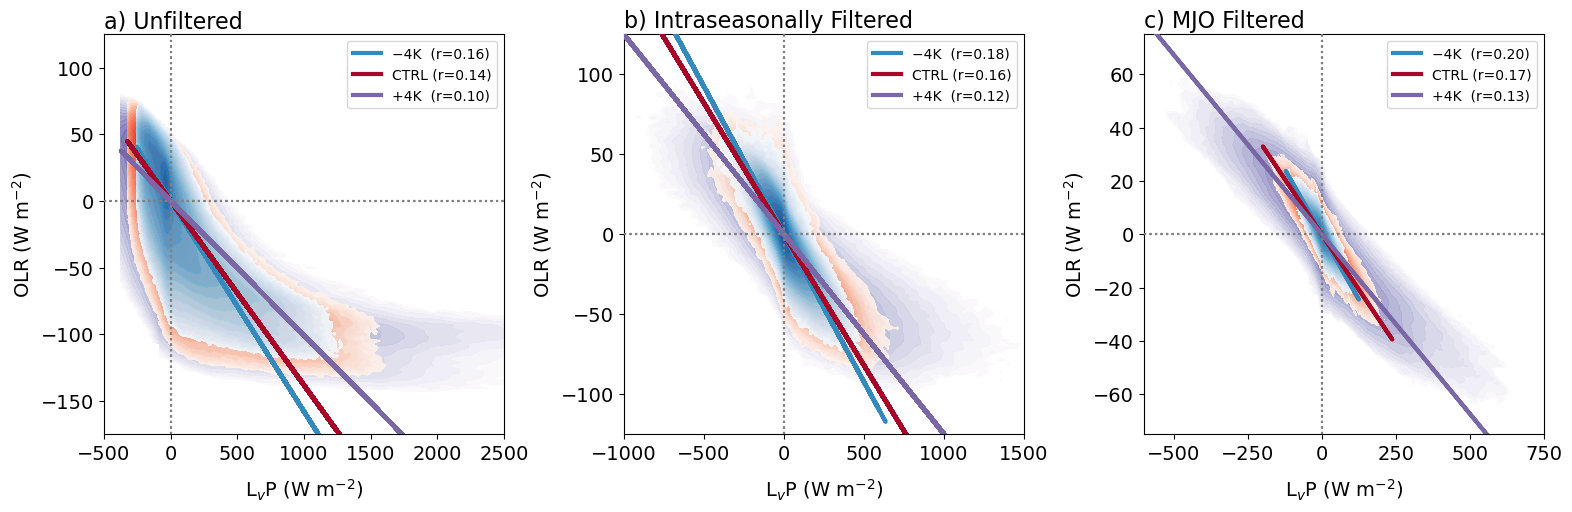

In [9]:
savefig = True

latitude_bounds = xr.DataArray(
    # [[-5, -10, -15], [5, 10, 15]],
    # [[-30, -30, -30], [30, 30, 30]],
    [[-15, -15, -15], [15, 15, 15]],
    dims=["bound", "experiment"],
    coords={"bound":['lower', 'upper'], "experiment": experiments_array}
)

experiment_cmaps = {}
experiment_cmaps['-4K'] = 'Blues'
experiment_cmaps['0K'] = 'Reds'
experiment_cmaps['4K'] = 'Purples'

all_variables_dict = {
    'Unfiltered': multi_experiment_variables_subset,
    'Intraseasonally Filtered': multi_experiment_variables_filtered,
    'MJO Filtered': multi_experiment_variables_mjo_filtered,
}

# Mask and filter
lat_mask = (
    (multi_experiment_variables_subset['Precipitation'].lat >= latitude_bounds.sel(bound='lower')) &
    (multi_experiment_variables_subset['Precipitation'].lat <= latitude_bounds.sel(bound='upper'))
)

N = np.size(multi_experiment_variables_subset['Precipitation'].sel(experiment='4K').values)
t_critical = t.ppf(0.95, df=N-2)

recalculate = False
if recalculate or 'r_estimate' not in locals():
    denominator, numerator, r_estimate, intercept = {}, {}, {}, {}
    for dict_name, dict_values  in all_variables_dict.items():
        denominator[dict_name] = (HEAT_OF_VAPORIZATION/SECONDS_PER_DAY)*standardize_data(
            dict_values['Precipitation'],
            dim='time',
            unit_variance=False
        ).where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
        denominator[dict_name] = standardize_data(
            denominator[dict_name],
            dim='grid_points',
            unit_variance = False
        )

        numerator[dict_name] = standardize_data(
            # -(dict_values[f'Column Longwave Heating']+dict_values[f'Column Shortwave Heating']),
            dict_values[f'Outgoing Longwave Radiation'],
            dim='time', unit_variance=False
        ).where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
        numerator[dict_name] = standardize_data(numerator[dict_name], dim='grid_points', unit_variance = False)

        # denominator[dict_name] = HEAT_OF_VAPORIZATION/SECONDS_PER_DAY*dict_values['Precipitation'].where(
        #     lat_mask, drop=True
        # ).stack(grid_points=(['time', 'lat', 'lon']))
        # numerator[dict_name] =  dict_values[f'Outgoing Longwave Radiation'].where(
        # lat_mask, drop=True
        # ).stack(grid_points=(['time', 'lat', 'lon']))

        r_estimate[dict_name] = xr.zeros_like(experiments_array).astype('float64')
        intercept[dict_name] = xr.zeros_like(experiments_array).astype('float64')
        for experiment_index, experiment in enumerate(experiments_list):
            r_estimate[dict_name][experiment_index], intercept[dict_name][experiment_index] = np.polyfit(
                y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
                x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
                deg=1
            )
            predicted_value = r_estimate[dict_name][experiment_index] * denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')
            residual_sum_of_squares = ((r_estimate[dict_name][experiment_index] - predicted_value) ** 2).sum(dim=['grid_points'])
            residual_variance = residual_sum_of_squares / (N - 2)
            standard_error_slope = np.sqrt(residual_variance / (N - 1))
            t_statistic = r_estimate[dict_name][experiment_index] / standard_error_slope

fontsize = 14
plt.rcParams.update({'font.size':fontsize})
plt.rcParams['mathtext.fontset'] = 'dejavusans'
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 3, wspace=0.3)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

axes_list = []
axes_list.append(fig.add_subplot(gs[0]))
axes_list.append(fig.add_subplot(gs[1]))
axes_list.append(fig.add_subplot(gs[2]))

for ax_index, (ax, (dict_name, dict_values))  in enumerate(zip(axes_list, all_variables_dict.items())):
    ax.set_title(f'{string.ascii_letters[ax_index]}) {dict_name}', loc='left', pad=5, fontsize=fontsize+2)
    for index, experiment in enumerate(experiments_list):

        counts,xbins,ybins = np.histogram2d(
            x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
            y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
            bins=[100, 100],
        )
        im = ax.contourf(
            np.log10(counts.transpose()),
            # counts.transpose(),
            extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
            cmap=experiment_cmaps[experiment],
            # levels = np.linspace(10, np.nanmax(counts), 21),
            levels=np.linspace(np.log10(10), 6, 21),
            alpha=0.9,
            zorder = 4-index
        )
        ax.plot(
                denominator[dict_name].sel(experiment=experiment),
                (r_estimate[dict_name]*denominator[dict_name]+intercept[dict_name]).sel(experiment=experiment),
                color=bmh_colors(index+1),
                lw=3,
                label=f"{experiments_array.sel(experiment=experiment)['name'].item():<4} (r={-r_estimate[dict_name].sel(experiment=experiment):>1.2f})",
                zorder=10,
            )
        ax.legend(fontsize=10, loc='upper right', facecolor='white')
        ax.axhline(y=0, color='gray', ls=':', zorder=10)
        ax.axvline(x=0, color='gray', ls=':', zorder=10)

        ax.set_xlabel(r'L$_v$P (W m$^{-2}$)', labelpad=10, fontsize=fontsize)
        ax.set_ylabel(rf'OLR (W m$^{{{-2}}}$)', labelpad=5, fontsize=fontsize)
        # ax.set_ylabel(rf'$\langle$LW$\rangle$ (W m$^{{{-2}}}$)', labelpad=5)
        # ax.set_ylabel(rf'$\langle$LW$\rangle$ + $\langle$SW$\rangle$ (W m$^{{{-2}}}$)', labelpad=5)
        ax.set_facecolor('white')
        ax.grid(False)
        # ax.set_aspect('equal')

    axes_list[0].set_ylim(-175, 125)
    axes_list[0].set_xlim(-500, 2500)
    # axes_list[0].set_ylim(100, 400)
    # axes_list[0].set_xlim(-500, 2500)

    axes_list[1].set_ylim(-125, 125)
    axes_list[1].set_xlim(-1000, 1500)

    axes_list[2].set_ylim(-75, 75)
    axes_list[2].set_xlim(-600, 750)

for axis in axes_list:
    axis.set_aspect((axis.get_xlim()[1] - axis.get_xlim()[0])/(axis.get_ylim()[1] - axis.get_ylim()[0]))

# Save figure
output_filename = f"Cloud-Radiative Feedback Parameter Scatter Plot - Log(Histogram)"
print(f"Output directory: {aquaplanet_output_directory}/gross_moist_stability_analysis/")
print(f"Output filename: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{str_width-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/gross_moist_stability_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

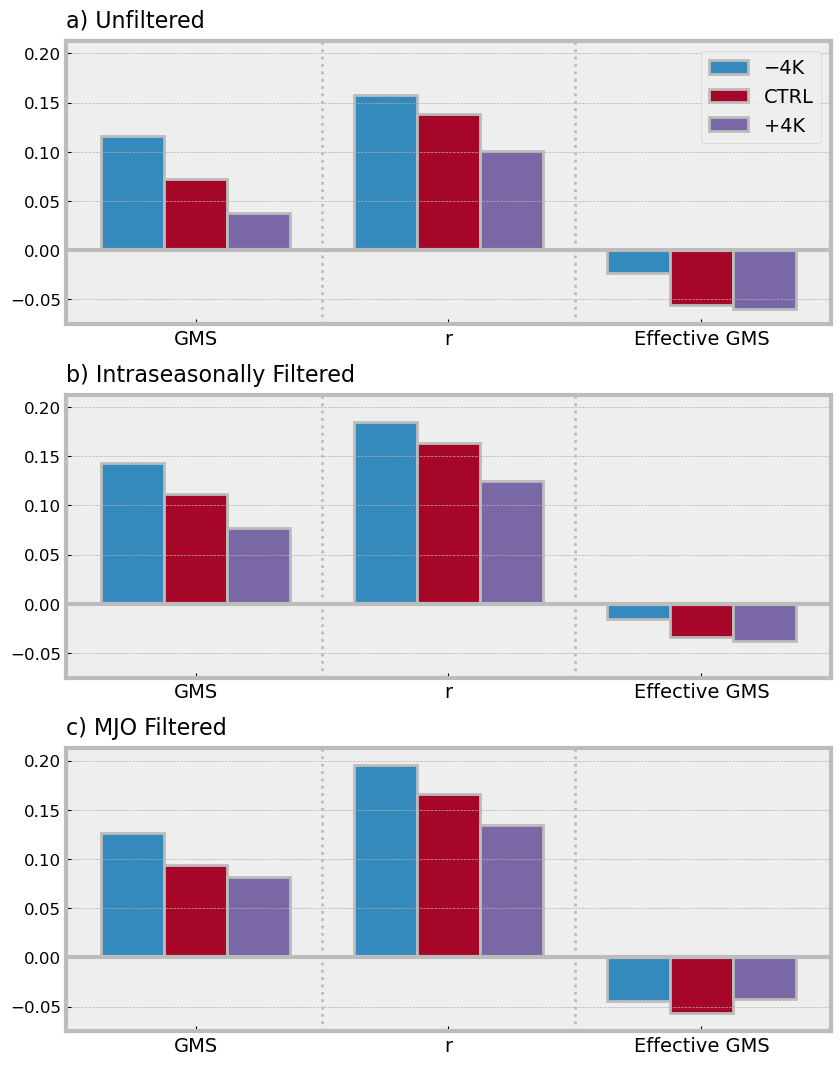

In [29]:
# timescale = 'Unfiltered'
timescale = 'Intraseasonally Filtered'
# timescale = 'MJO Filtered'
effective_GMS = {}

bar_width = 0.25

plt.style.use('bmh')
plt.rcParams.update({'font.size': 12, 'mathtext.fontset': 'dejavusans'})

# fig = plt.figure(figsize=(16, 12))
fig = plt.figure(figsize=(8.5, 11))
gs = GridSpec(3, 1, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.25)

ax = []
ax.append(fig.add_subplot(gs[0]))
ax.append(fig.add_subplot(gs[1]))
ax.append(fig.add_subplot(gs[2]))

for filt_index, timescale in enumerate(['Unfiltered', 'Intraseasonally Filtered', 'MJO Filtered']):

    GMS_estimate[timescale].name = 'GMS'
    r_estimate[timescale].name = 'r'
    r_estimate[timescale] = np.abs(r_estimate[timescale])
    effective_GMS[timescale] = GMS_estimate[timescale]*(1+r_estimate[timescale]) - r_estimate[timescale]
    effective_GMS[timescale].name = 'Effective GMS'

    ax[filt_index].set_title(
        f"{string.ascii_letters[filt_index]}) {timescale}",
        loc='left',
        pad=10,
        fontsize=fontsize+2
    )

    processes_to_plot = [
        GMS_estimate[timescale],
        r_estimate[timescale],
        effective_GMS[timescale]
    ]

    x_positions = np.arange(len(processes_to_plot))
    for i, experiment in enumerate(experiments_list):
        plot_label = (f"{experiments_array.sel(experiment=experiment)['name'].item()}")
        ax[filt_index].bar(
            x_positions + i * bar_width,
            [process.sel(experiment=experiment).values for process in processes_to_plot],
            width=bar_width,
            label=plot_label,
            # color=[budget_term_attributes[process]['color'](0.3 + 0.35 * i) for process in processes_to_plot],
            edgecolor='#bcbcbc',
            lw=2,
        )

for axis in ax:
    axis.set_ylim(-0.075, 0.2125)
    axis.set_xticks(x_positions + bar_width, labels=[process.name for process in processes_to_plot], fontsize=fontsize)
    axis.axhline(y=0, color='#bcbcbc', lw=3)
    axis.grid(axis='x')
    [axis.axvline(x=(position + 3*bar_width), ls=':', color='#bcbcbc') for position in x_positions[:-1]]

    for spine in axis.spines.values():
        spine.set_edgecolor("#bcbcbc")
        spine.set_linewidth(3)

ax[0].legend(fontsize=fontsize)
plt.show()

Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//gross_moist_stability_analysis/
Output filename: Effective GMS Contourf Plot
Saving...                              ✔


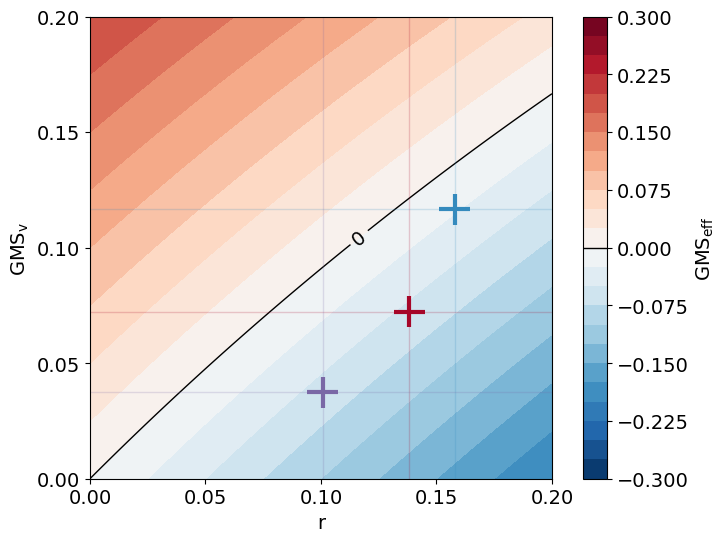

In [53]:
savefig = True

# r = np.linspace(0.05, 0.2, 100)
r = np.linspace(0.0, 0.2, 100)
# gamma = np.linspace(0.02, 0.2, 100)
gamma = np.linspace(0.0, 0.2, 100)

[R, G] = np.meshgrid(r, gamma)

G_eff = G*(1+R) - R

plt.style.use('default')
plt.rcParams.update({'font.size':14})
[fig, ax] = plt.subplots(figsize=(6, 6))

cf = ax.contourf(
    R, G, G_eff,
    cmap='RdBu_r',
    norm=mcolors.CenteredNorm(vcenter=0),
    levels=np.arange(-0.3, 0.325, 0.025)
)

# Define colorbar width (in figure coordinates)
cbar_width = 0.5
pad = 1

cax = fig.add_axes(
    [
        ax.get_position().x1+0.05,
        ax.get_position().y0,
        0.04,
        ax.get_position().height
    ]
)

cbar = fig.colorbar(cf, cax=cax)
cbar.ax.hlines(0, 0, 1, colors='k', linewidth=1, linestyles='-')
cbar.set_label(r"GMS$_\text{eff}$")

cs = ax.contour(
    R,
    G,
    G_eff,
    colors='k',
    levels=[0],
    linewidths=1
)
ax.clabel(cs, colors='k', fmt='%1.0f', inline=True, manual=[(0.12, 0.1)])

ax.scatter(
    -r_estimate['Unfiltered'],
    GMS_estimate['Unfiltered'],
    color=[bmh_colors(1), bmh_colors(2), bmh_colors(3)],
    s=500,
    marker='+',
    linewidths=3,
)
for index, experiment in enumerate(experiments_list):
    ax.axvline(-r_estimate['Unfiltered'].sel(experiment=experiment), color=bmh_colors(index+1), ls='-', alpha=0.2, linewidth=1)
    ax.axhline(GMS_estimate['Unfiltered'].sel(experiment=experiment), color=bmh_colors(index+1), ls='-', alpha=0.2, linewidth=1)

ax.set_xlabel('r')
ax.set_xticks(np.arange(0, 0.25, 0.05))
ax.set_xlim(0.0, 0.2)

ax.set_ylabel(r'GMS$_\text{v}$')
ax.set_yticks(np.arange(0, 0.25, 0.05))
ax.set_ylim(0.0, 0.2)

ax.set_aspect('equal', adjustable='box')

# Save figure
output_filename = f"Effective GMS Contourf Plot"
print(f"Output directory: {aquaplanet_output_directory}/gross_moist_stability_analysis/")
print(f"Output filename: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{str_width-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/gross_moist_stability_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

In [19]:
# data_directory = "/glade/derecho/scratch/sressel"
data_directory = r"/glade/campaign/univ/uwas0152/post_processed_data/"
# budget_to_load = 'MSE'
budget_to_load = 'moisture'
# budget_to_load = 'meridional_moisture_advection'
# data_source_to_load = '3-hourly_model-level'
# data_source_to_load = 'daily_pressure-level'
data_source_to_load = 'daily_model-level'

# processes_to_load = 'single decomposed advection term'
# processes_to_load = 'full budget with decomposed advection terms'
processes_to_load = 'full budget'

multi_experiment_budget_variables = {}
print("Loading budget variables...")
print(f"{'='*str_width}")
budget_data_location = f"{data_directory}/{budget_to_load}_budget_terms/{data_source_to_load}_data"
if budget_to_load == 'MSE':
    budget_variables_to_load = [
        'Moist Static Energy',
        'Moist Static Energy Tendency',
        'Zonal Advection',
        'Meridional Advection',
        'Vertical Advection',
        'Latent Heating',
        'Sensible Heating',
        'Longwave Heating',
        'Shortwave Heating',
        'Residual'
    ]

elif budget_to_load == 'moisture':
    if processes_to_load == 'full budget':
        budget_variables_to_load = [
            'Moisture',
            'Moisture Tendency',
            'Zonal Advection',
            'Meridional Advection',
            'Vertical Advection',
            'Evaporation',
            'Precipitation',
            'Residual'
        ]

    elif processes_to_load == 'single decomposed advection term':
        advection_type = 'Meridional Advection'
        budget_variables_to_load = [
            'Precipitation',
            'Moisture',
            'Moisture Tendency',
            f'{advection_type}',
            f'{advection_type} Mean wind mean moisture',
            f'{advection_type} Mean wind MJO moisture',
            f'{advection_type} Mean wind residial moisture',
            f'{advection_type} MJO wind mean moisture',
            f'{advection_type} MJO wind MJO moisture',
            f'{advection_type} MJO wind residual moisture',
            f'{advection_type} Residual wind mean moisture',
            f'{advection_type} Residual wind MJO moisture',
            f'{advection_type} Residual wind residual moisture',
        ]

    elif processes_to_load == 'full budget with decomposed advection terms':
        budget_variables_to_load = [
            'Moisture',
            'Moisture Tendency',
            'Evaporation',
            'Precipitation',
            f'Zonal Advection Mean wind MJO moisture',
            f'Zonal Advection Residual wind residual moisture',
            f'Meridional Advection MJO wind mean moisture',
            f'Meridional Advection Residual wind residual moisture',
            f'Vertical Advection MJO wind mean moisture',
            'Residual'
        ]

for index, variable_name in enumerate(budget_variables_to_load):
    data = xr.open_dataset(f"{budget_data_location}/multi_experiment_{variable_name.lower().replace(' ', '_')}.nc")
    for variable_data in data.data_vars.values():
        print(f"{f'({index+1}/{len(budget_variables_to_load)}) {variable_name}...':<{str_width-1}}", end="")
        multi_experiment_budget_variables[variable_name] = variable_data
        print(rf"{'✔':>1}")

print(f"{'='*str_width}")
print("Finished")

Loading budget variables...
(1/8) Moisture...                      ✔
(2/8) Moisture Tendency...             ✔
(3/8) Zonal Advection...               ✔
(4/8) Meridional Advection...          ✔
(5/8) Vertical Advection...            ✔
(6/8) Evaporation...                   ✔
(7/8) Precipitation...                 ✔
(8/8) Residual...                      ✔
Finished


In [23]:
print(f"{'Subset budget variables':^{str_width}}")
print(f"{'='*str_width}")

multi_experiment_budget_variables_subset = {}

for index, (variable_name, variable_data) in enumerate(multi_experiment_budget_variables.items()):
    print(f"{f'({index+1}/{len(multi_experiment_budget_variables)}) {variable_name}...':<{str_width-1}}", end="")

    multi_experiment_budget_variables_subset[variable_name] = variable_data.drop_sel(time=missing_timesteps, errors='ignore')
    print(rf"{'✔':>1}")

# multi_experiment_budget_variables_subset[reference_variable] = variable_data.drop_sel(time=missing_timesteps, errors='ignore')

print(f"{'='*str_width}")
print("Finished")

        Subset budget variables         
(1/8) Moisture...                      ✔
(2/8) Moisture Tendency...             ✔
(3/8) Zonal Advection...               ✔
(4/8) Meridional Advection...          ✔
(5/8) Vertical Advection...            ✔
(6/8) Evaporation...                   ✔
(7/8) Precipitation...                 ✔
(8/8) Residual...                      ✔
Finished


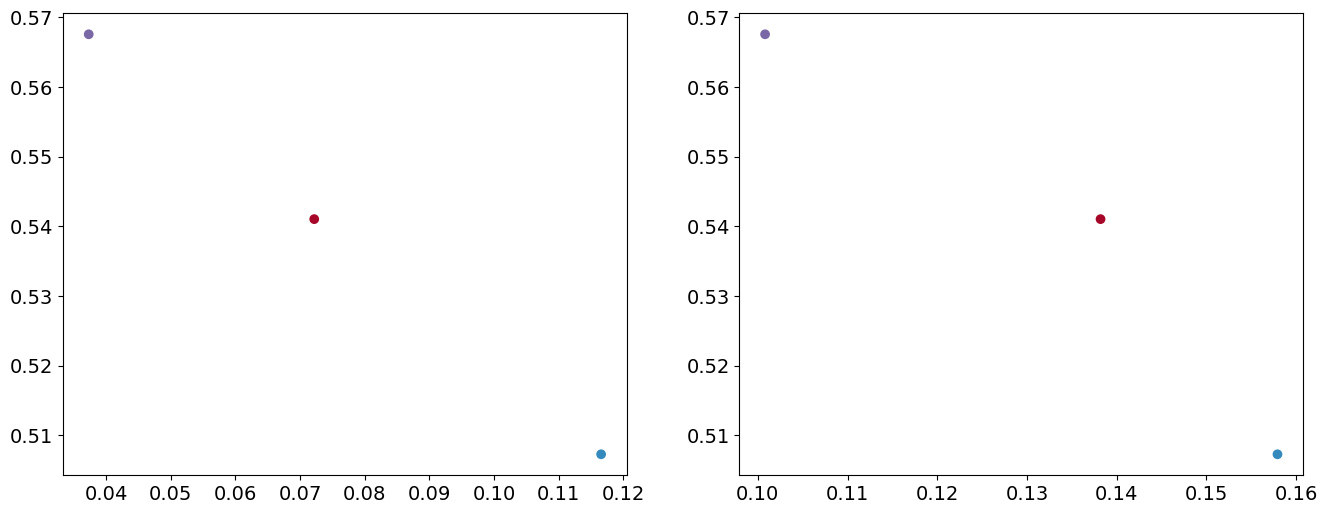

In [42]:
[fig, ax] = plt.subplots(1, 2, figsize=(16,6))
ax[0].scatter(
    GMS_estimate['Unfiltered'],
    SECONDS_PER_DAY*multi_experiment_budget_variables_subset['Vertical Advection'].sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon'])/multi_experiment_variables_subset['Precipitation'].sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon']),
    color=[bmh_colors(1), bmh_colors(2), bmh_colors(3)]
)

ax[1].scatter(
    -r_estimate['Unfiltered'],
    SECONDS_PER_DAY*multi_experiment_budget_variables_subset['Vertical Advection'].sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon'])/multi_experiment_variables_subset['Precipitation'].sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon']),
    color=[bmh_colors(1), bmh_colors(2), bmh_colors(3)]
)

<xarray.DataArray 'Precipitation' (experiment: 3, time: 3648, lat: 34, lon: 144)> Size: 429MB
array([[[[1.83108903e-05, 6.19001861e-06, 1.15386168e-03, ...,
          2.29598407e-01, 1.31941258e-03, 1.31415613e-03],
         [8.60412925e-02, 2.70023314e-03, 1.90123589e-02, ...,
          1.60544738e-02, 4.53847272e-04, 9.00778672e-03],
         [4.41443490e-02, 6.25117258e-03, 2.96444653e-02, ...,
          3.37916536e-01, 2.35080940e-01, 3.22804103e-02],
         ...,
         [7.64861262e-02, 2.35367262e-02, 2.19202101e-03, ...,
          4.40568132e-01, 4.57026954e-01, 2.73735716e-01],
         [3.01176620e-02, 1.98509057e-02, 1.28206689e-02, ...,
          4.07538528e-01, 3.60082907e-01, 3.01470298e-01],
         [4.10508159e-01, 2.46730514e-01, 8.93607652e-02, ...,
          1.03304711e+00, 6.93654158e-01, 5.71985467e-01]],

        [[9.15698292e-04, 4.31483784e-06, 1.14618025e-03, ...,
          4.78062083e-01, 5.21831890e-02, 6.30607486e-03],
         [1.25707349e-01, 3.17145470e-03, 4.56196268e-05, ...,
          7.30358391e-01, 2.94521406e-01, 7.71998145e-02],
         [1.15810314e-03, 7.70350109e-04, 2.58511314e-05, ...,
          1.22827099e+00, 2.16353054e-01, 9.20845064e-02],
...
         [1.16682776e+00, 5.85095415e-01, 2.90616542e-01, ...,
          1.53209720e+00, 1.52047007e+00, 1.38302645e+00],
         [7.85741571e-01, 4.64550254e-01, 2.15932833e-01, ...,
          9.08931298e-01, 9.78706728e-01, 1.06849889e+00],
         [6.09093000e-01, 5.03246353e-01, 3.16077455e-01, ...,
          6.78383020e-01, 5.06277068e-01, 6.39031650e-01]],

        [[2.59525321e-02, 1.23072864e-01, 3.48671760e-01, ...,
          8.46072396e-02, 1.09849995e-01, 3.63284778e-02],
         [2.26832326e-01, 1.66907198e-01, 1.56077893e-01, ...,
          3.76678119e-03, 5.82322710e-03, 4.23062337e-02],
         [2.87443784e-01, 2.13084066e-01, 1.91211335e-01, ...,
          1.23897169e-02, 3.03467593e-01, 2.99503679e-01],
         ...,
         [9.47723436e-01, 2.80014488e-01, 1.25578188e-01, ...,
          1.85694880e+00, 1.71182180e+00, 1.42840445e+00],
         [9.82567218e-01, 7.16572606e-01, 4.79596778e-01, ...,
          1.10928140e+00, 1.18073011e+00, 1.11829427e+00],
         [6.00093824e-01, 6.35237232e-01, 7.03259607e-01, ...,
          6.24820426e-01, 4.66321842e-01, 6.36000436e-01]]]])
Coordinates:
  * lat         (lat) float64 272B -31.26 -29.37 -27.47 ... 27.47 29.37 31.26
  * lon         (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time        (time) object 29kB 0003-01-03 00:00:00 ... 0013-01-03 00:00:00
  * experiment  (experiment) <U3 36B '-4K' '0K' '4K'
Attributes:
    description:  Sum of large scale and convective precipitation
    units:        mm day$^{-1}$
    file_id:      PRCP
    short_name:   PRCP
    subset:       True